# Transfer Learning for Fake Reviews Across Domain Boundaries

**Cross-Domain Generalization in Fake Review Detection**

> *Investigating how machine learning models trained on one platform (e.g., Amazon)
> can effectively detect fake reviews on another platform (e.g., Yelp).*

## Abstract

This study investigates cross-domain transfer learning for fake review detection. We analyze two major platforms — Amazon (~40K reviews) and Yelp (~359K reviews) — and evaluate how models trained on one domain generalize to another. Using classical classifiers (Logistic Regression, Linear SVM, Random Forest, XGBoost) on combined TF-IDF and linguistic features, we show that **Yelp → Amazon transfer outperforms the reverse direction**, highlighting the importance of source-domain diversity in training data.

## Research Objectives

1. **Primary objective:** evaluate cross-domain transfer performance in fake review detection.
2. **Secondary objectives:**
   - Analyze domain-specific linguistic patterns.
   - Identify features relevant to cross-domain generalization.
   - Measure the effect of few-shot domain adaptation.

## Methodology Overview

- **Approach:** supervised learning under a transfer-learning paradigm.
- **Features:** TF-IDF (unigrams + bigrams) + linguistic/style metadata.
- **Models:** Logistic Regression, Linear SVM, Random Forest, XGBoost.
- **Evaluation:** Accuracy, Precision, Recall, F1-score, ROC-AUC.
- **Transfer directions:** Amazon → Yelp and Yelp → Amazon.

> **How to run:** execute cells top to bottom. No outputs are stored in this file; all figures and tables are generated when you run it yourself.


## Table of Contents

1. [Introduction](#1-introduction)
2. [Data Preparation](#2-data-preparation)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Transfer Learning Methodology](#5-transfer-learning-methodology)
6. [Model Training](#6-model-training)
7. [Model Evaluation](#7-model-evaluation)
8. [Results & Analysis](#8-results--analysis)
9. [Domain Adaptation](#9-domain-adaptation)
10. [Discussion & Conclusion](#10-discussion--conclusion)


## 1. Introduction

Fake reviews erode consumer trust in online marketplaces. A detector trained on one platform often degrades on another because of **domain drift**: different review lengths, vocabularies, rating behavior, and writing conventions. This notebook frames that problem as **transfer learning across domain boundaries**: train on a source domain, test on a target domain, and quantify the gap.

**Research questions:**

1. How well do classical fake-review detectors transfer across platforms?
2. Does transfer direction matter (Amazon → Yelp vs. Yelp → Amazon)?
3. Do small amounts of target-domain data close the gap (domain adaptation)?


### Environment Setup

What: import all libraries and set publication-style figure defaults (consistent colors, fonts, and gridlines for every plot). Why: a single style block keeps all downstream visualizations comparable and portfolio-ready.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import html
import string
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud

from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from scipy.sparse import hstack

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

# Color scheme
GENUINE_COLOR = '#2E8B57'
FAKE_COLOR = '#DC143C'

print('All libraries imported successfully')

# Publication-style figure defaults (consistent across all plots)
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

All libraries imported successfully


## 2. Data Preparation

### 2.1 Dataset Description

Two large-scale review datasets from distinct domains:

| Dataset | Platform | Size | Label encoding |
|---------|----------|------|----------------|
| Amazon | E-commerce product reviews | ~40K | `CG` → 1 (fake), `OR` → 0 (genuine) |
| Yelp | Restaurant/service reviews | ~359K | `-1` → 1 (fake), `1` → 0 (genuine) |

**Domain characteristics:** Amazon reviews are shorter and more formulaic; Yelp reviews are longer and more narrative. That stylistic gap is exactly what makes transfer nontrivial.

### 2.2 Preprocessing Pipeline

1. **Label standardization** — unify both datasets to `1 = fake`, `0 = genuine`.
2. **Deduplication** — drop exact duplicate reviews to avoid leakage.
3. **Text cleaning** — decode HTML, strip URLs/emails/tags, normalize whitespace.
4. **Balancing** — undersample Yelp to 25K per class for fair cross-domain comparison.
5. **Filtering** — drop reviews shorter than 20 characters (insufficient signal).


What: load both CSVs and inspect shapes, columns, and missing values. Why: the two files use different schemas that must be reconciled before any comparison.

In [2]:
amazon_df = pd.read_csv('fake reviews dataset.csv')
yelp_df = pd.read_csv('Labelled Yelp Dataset.csv')

print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Amazon Dataset Shape: {amazon_df.shape}')
print(f'Yelp Dataset Shape: {yelp_df.shape}\n')

print('AMAZON - Column Names:')
print(amazon_df.columns.tolist())
print(f'Missing Values:\n{amazon_df.isnull().sum()}\n')

print('YELP - Column Names:')
print(yelp_df.columns.tolist())
print(f'Missing Values:\n{yelp_df.isnull().sum()}\n')

print('\nAmazon Sample:')
print(amazon_df.head(2))
print('\nYelp Sample:')
print(yelp_df.head(2))

DATASET OVERVIEW
Amazon Dataset Shape: (40432, 4)
Yelp Dataset Shape: (359052, 6)

AMAZON - Column Names:
['category', 'rating', 'label', 'text_']
Missing Values:
category    0
rating      0
label       0
text_       0
dtype: int64

YELP - Column Names:
['User_id', 'Product_id', 'Rating', 'Date', 'Review', 'Label']
Missing Values:
User_id       0
Product_id    0
Rating        0
Date          0
Review        0
Label         0
dtype: int64


Amazon Sample:
             category  rating label  \
0  Home_and_Kitchen_5     5.0    CG   
1  Home_and_Kitchen_5     5.0    CG   

                                                                              text_  
0       Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty  
1  love it, a great upgrade from the original.  I've had mine for a couple of years  

Yelp Sample:
   User_id  Product_id  Rating       Date  \
0      923           0       3  12/8/2014   
1      924           0       3  5/16/2013   

               

What: rename columns and map labels to a shared `{rating, review, label}` schema. Why: Yelp's original `Label` column (capital L) and `-1/1` encoding differ from Amazon's `CG/OR` labels — standardizing first prevents silent mislabeling downstream.

In [3]:
# ===== AMAZON: Standardize columns and labels =====
amazon_df['label'] = amazon_df['label'].map({'CG': 1, 'OR': 0})
amazon_df = amazon_df.rename(columns={'text_': 'review'})
amazon_df = amazon_df[['rating', 'review', 'label']]
amazon_df['rating'] = amazon_df['rating'].astype(int)

# ===== YELP: Rename columns FIRST (original column is 'Label' with capital L), then map labels =====
yelp_df = yelp_df.rename(columns={'Rating': 'rating', 'Review': 'review', 'Label': 'label'})
yelp_df = yelp_df[['rating', 'review', 'label']]
yelp_df['label'] = yelp_df['label'].map({-1: 1, 1: 0})  # -1 (fake) -> 1, 1 (genuine) -> 0

print('AMAZON standardized:')
print(f'  Shape: {amazon_df.shape}')
print(f'  Class distribution:\n{amazon_df["label"].value_counts().sort_index().to_string()}\n')

print('YELP standardized:')
print(f'  Shape: {yelp_df.shape}')
print(f'  Class distribution:\n{yelp_df["label"].value_counts().sort_index().to_string()}')

AMAZON standardized:
  Shape: (40432, 3)
  Class distribution:
label
0    20216
1    20216

YELP standardized:
  Shape: (359052, 3)
  Class distribution:
label
0    322167
1     36885


What: remove exact duplicate review texts. Why: duplicates inflate class counts and can leak near-identical examples across train/test splits.

In [4]:
amazon_before = len(amazon_df)
amazon_df = amazon_df.drop_duplicates(subset='review').reset_index(drop=True)

yelp_before = len(yelp_df)
yelp_df = yelp_df.drop_duplicates(subset='review').reset_index(drop=True)

print('DUPLICATES REMOVED:')
print(f'  Amazon: {amazon_before:,} -> {len(amazon_df):,} records (removed {amazon_before - len(amazon_df):,})')
print(f'  Yelp: {yelp_before:,} -> {len(yelp_df):,} records (removed {yelp_before - yelp_df.shape[0]:,})')

DUPLICATES REMOVED:
  Amazon: 40,432 -> 40,412 records (removed 20)
  Yelp: 359,052 -> 358,156 records (removed 896)


What: define a text cleaner, audit HTML/URL/email noise, then apply cleaning and drop empties. Why: TF-IDF and linguistic features must reflect review content, not markup or links.

In [5]:
def clean_review(text):
    text = str(text)
    text = html.unescape(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[ÂâÃ]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def count_patterns(df, column):
    text = df[column].fillna('').astype(str)
    return {
        'html_tags': text.str.contains(r'<.*?>', regex=True).sum(),
        'urls': text.str.contains(r'http\S+|www\.\S+', regex=True).sum(),
        'emails': text.str.contains(r'\S+@\S+', regex=True).sum()
    }

print('Pattern Detection (before cleaning):')
print(f'  Amazon: {count_patterns(amazon_df, "review")}')
print(f'  Yelp: {count_patterns(yelp_df, "review")}')

amazon_df['review'] = amazon_df['review'].apply(clean_review)
yelp_df['review'] = yelp_df['review'].apply(clean_review)

amazon_before = len(amazon_df)
amazon_df = amazon_df[amazon_df['review'].str.len() > 0].reset_index(drop=True)

yelp_before = len(yelp_df)
yelp_df = yelp_df[yelp_df['review'].str.len() > 0].reset_index(drop=True)

print('TEXT CLEANED & NORMALIZED:')
print(f'  Amazon: removed {amazon_before - len(amazon_df)} empty reviews -> {len(amazon_df):,} records')
print(f'  Yelp: removed {yelp_before - len(yelp_df)} empty reviews -> {len(yelp_df):,} records')

Pattern Detection (before cleaning):
  Amazon: {'html_tags': np.int64(203), 'urls': np.int64(109), 'emails': np.int64(11)}
  Yelp: {'html_tags': np.int64(0), 'urls': np.int64(33), 'emails': np.int64(215)}
TEXT CLEANED & NORMALIZED:
  Amazon: removed 0 empty reviews -> 40,412 records
  Yelp: removed 0 empty reviews -> 358,156 records


What: plot per-domain class distributions, then balance Yelp (25K genuine + 25K fake). Why: raw Yelp is ~90% genuine, so an unbalanced setup would reward trivial majority-class predictions and distort the transfer comparison.

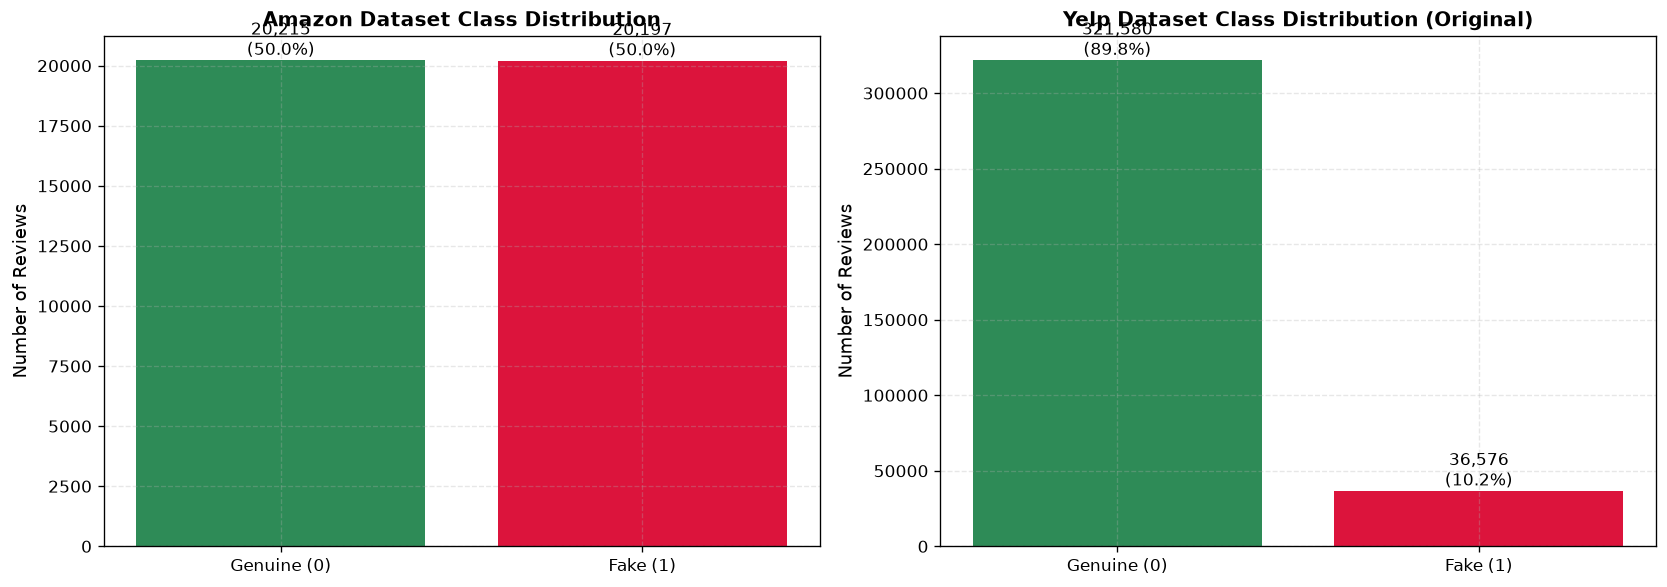


Yelp Balanced (50-50 split): 50,000 records
label
0    25000
1    25000
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amazon
amazon_counts = amazon_df['label'].value_counts().sort_index()
axes[0].bar(['Genuine (0)', 'Fake (1)'], amazon_counts.values, color=[GENUINE_COLOR, FAKE_COLOR])
axes[0].set_title('Amazon Dataset Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(amazon_counts.values):
    axes[0].text(i, v, f'{v:,}\n({v/len(amazon_df)*100:.1f}%)', ha='center', va='bottom')

# Yelp (original)
yelp_counts = yelp_df['label'].value_counts().sort_index()
axes[1].bar(['Genuine (0)', 'Fake (1)'], yelp_counts.values, color=[GENUINE_COLOR, FAKE_COLOR])
axes[1].set_title('Yelp Dataset Class Distribution (Original)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Reviews')
for i, v in enumerate(yelp_counts.values):
    axes[1].text(i, v, f'{v:,}\n({v/len(yelp_df)*100:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Balance Yelp: 25k from each class
fake_yelp = yelp_df[yelp_df['label'] == 0].sample(n=25000, random_state=42)
genuine_yelp = yelp_df[yelp_df['label'] == 1].sample(n=25000, random_state=42)
yelp_sample = pd.concat([fake_yelp, genuine_yelp]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\nYelp Balanced (50-50 split): {len(yelp_sample):,} records')
print(yelp_sample['label'].value_counts().sort_index())

**Insight to look for:** Amazon is roughly balanced, while raw Yelp is heavily skewed — hence the 50K balanced Yelp sample used everywhere below.

## 3. Exploratory Data Analysis

Goal: characterize the **domain shift** before modeling — review length, vocabulary, and stylistic markers — so transfer results can be interpreted rather than just reported.

### 3.1 Review Length Analysis

What: compare length/word-count statistics per domain and drop reviews under 20 characters. Why: very short reviews carry almost no linguistic signal and add noise to cross-domain features.

In [7]:
def review_stats(df, name):
    print(f'--- {name} ---')
    print(f'  Empty reviews  : {(df["review"].str.len() == 0).sum()}')
    print(f'  Reviews < 20ch : {(df["review"].str.len() < 20).sum()}')
    print(f'  Avg length     : {df["review"].str.len().mean():.0f} chars')
    print(f'  Avg word count : {df["word_count"].mean():.0f} words')

# Need word_count first - compute it here for the stats
amazon_df['word_count'] = amazon_df['review'].str.split().apply(len)
yelp_sample['word_count'] = yelp_sample['review'].str.split().apply(len)

review_stats(amazon_df, 'Amazon')
print()
review_stats(yelp_sample, 'Yelp (Balanced)')

# Filter short reviews
amazon_before = len(amazon_df)
amazon_df = amazon_df[amazon_df['review'].str.len() >= 20].reset_index(drop=True)

yelp_before = len(yelp_sample)
yelp_sample = yelp_sample[yelp_sample['review'].str.len() >= 20].reset_index(drop=True)

print(f'\nAfter filtering (min 20 chars):')
print(f'  Amazon: {amazon_before:,} -> {len(amazon_df):,}')
print(f'  Yelp:   {yelp_before:,} -> {len(yelp_sample):,}')

--- Amazon ---
  Empty reviews  : 0
  Reviews < 20ch : 4
  Avg length     : 348 chars
  Avg word count : 67 words

--- Yelp (Balanced) ---
  Empty reviews  : 0
  Reviews < 20ch : 494
  Avg length     : 553 chars
  Avg word count : 102 words

After filtering (min 20 chars):
  Amazon: 40,412 -> 40,408
  Yelp:   50,000 -> 49,506


**Insight to look for:** Yelp reviews average substantially longer than Amazon reviews — the first concrete sign of domain shift.

## 4. Feature Engineering

### 4.1 Linguistic Features

AI-generated reviews often differ from human writing in vocabulary diversity and sentence structure. We capture that with:

| Feature | Description | Why it matters |
|---------|-------------|----------------|
| `text_length` | Character count | Overall verbosity |
| `word_count` | Token count | Information density |
| `sentence_count` | Sentence count | Structural complexity |
| `vocab_richness` | Unique words / total words | Lexical diversity (type-token ratio) |
| `avg_word_len` | Mean word length | Morphological complexity |

What: the next cell computes these features for both domains. Why: they form the dense side-channel that complements sparse TF-IDF text features.

In [8]:
def add_text_features(df):
    df = df.copy()
    df['text_length'] = df['review'].str.len()
    df['word_count'] = df['review'].str.split().apply(len)
    df['sentence_count'] = df['review'].apply(
        lambda x: len([s for s in nltk.sent_tokenize(x) if s.strip()])
    )
    return df

def vocab_richness(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return len(set(words)) / len(words)

def avg_word_length(text):
    words = text.split()
    if len(words) == 0:
        return 0
    return np.mean([len(word) for word in words])

amazon_df = add_text_features(amazon_df)
amazon_df['vocab_richness'] = amazon_df['review'].apply(vocab_richness)
amazon_df['avg_word_len'] = amazon_df['review'].apply(avg_word_length)

yelp_sample = add_text_features(yelp_sample)
yelp_sample['vocab_richness'] = yelp_sample['review'].apply(vocab_richness)
yelp_sample['avg_word_len'] = yelp_sample['review'].apply(avg_word_length)

print('Features computed for both datasets.')
print(f'Amazon shape: {amazon_df.shape}')
print(f'Yelp shape: {yelp_sample.shape}')

Features computed for both datasets.
Amazon shape: (40408, 8)
Yelp shape: (49506, 8)


### 4.2 Feature Distributions

What: overlaid genuine-vs-fake histograms per feature and domain. Why: to see which signals separate the classes *within* each domain before testing whether they survive *across* domains.

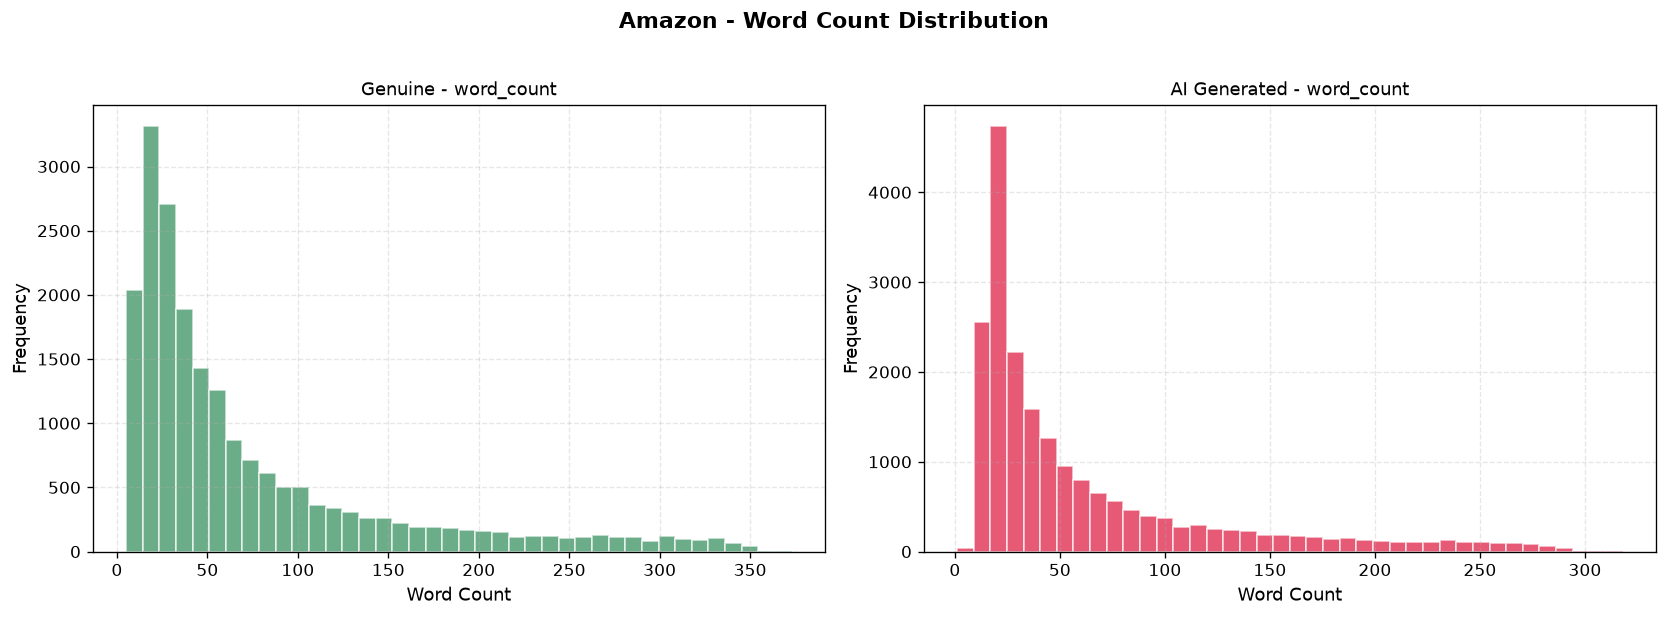

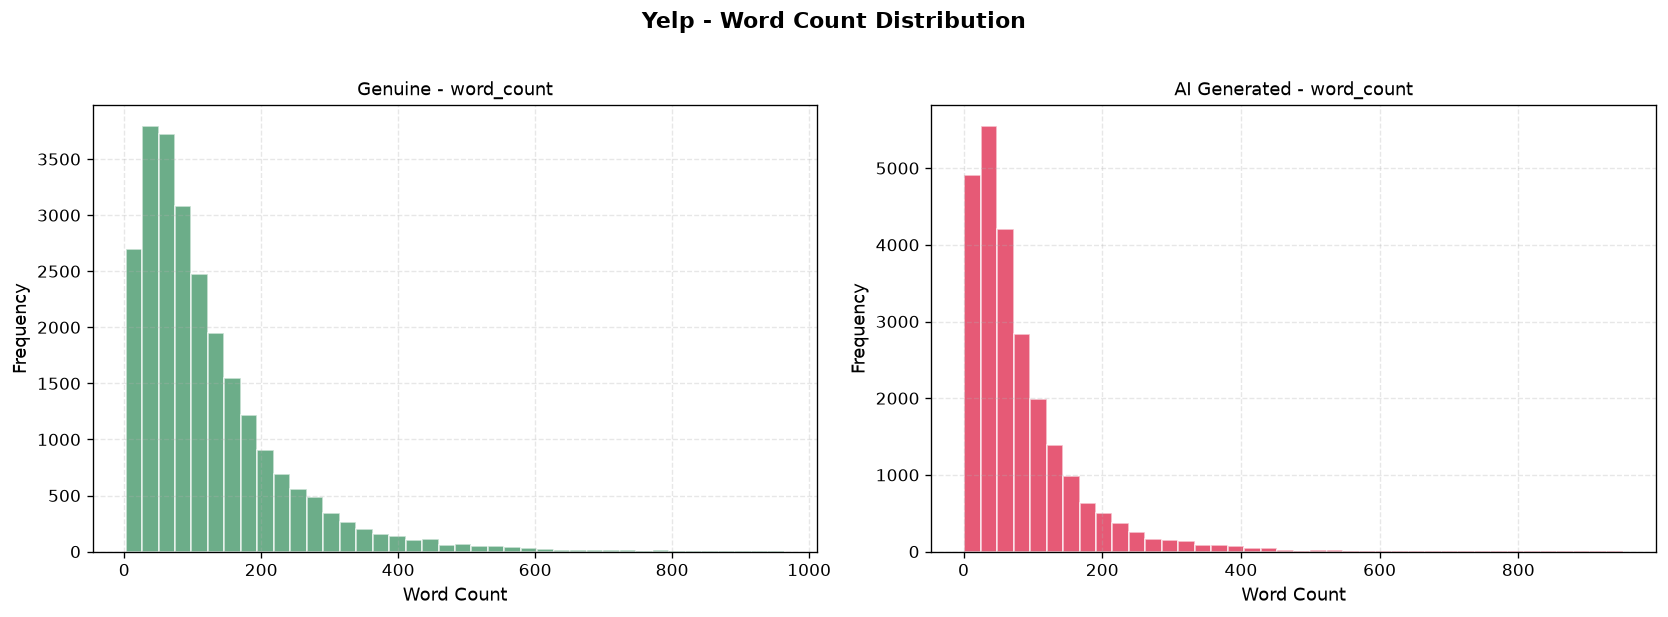

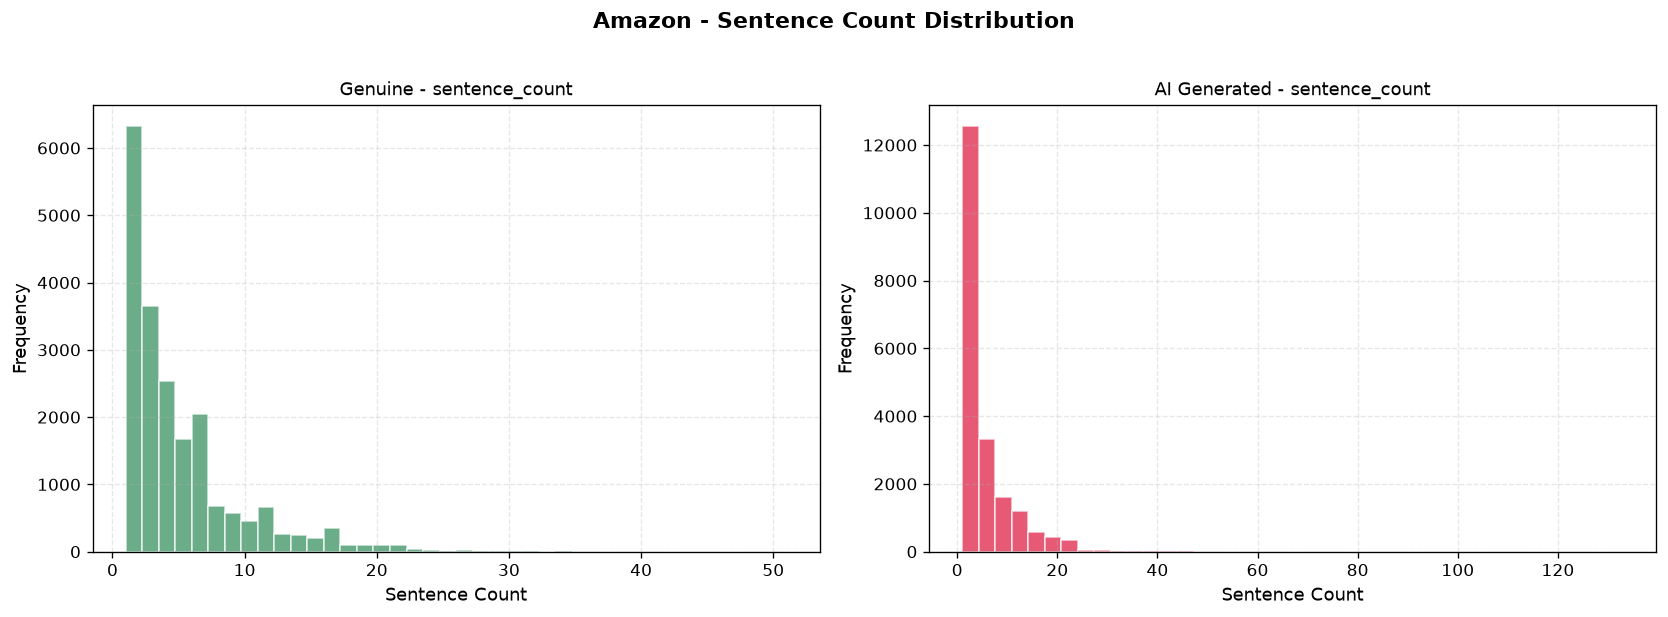

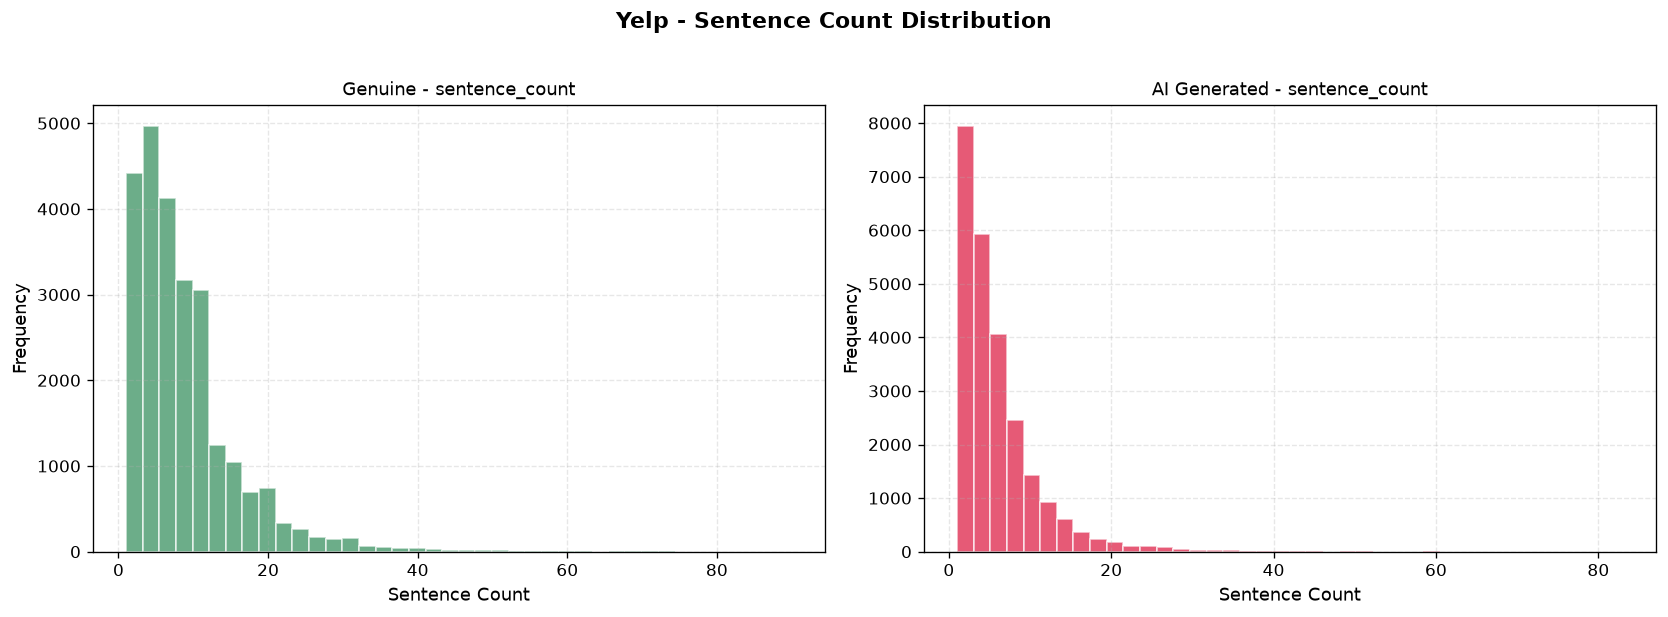

In [9]:
def plot_feature_distribution(df, feature, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label, color, name in zip(axes, [0, 1], [GENUINE_COLOR, FAKE_COLOR], ['Genuine', 'AI Generated']):
        data = df[df['label'] == label][feature]
        ax.hist(data, bins=40, alpha=0.7, color=color, edgecolor='white')
        ax.set_title(f'{name} - {feature}', fontsize=11)
        ax.set_xlabel(feature.replace('_', ' ').title())
        ax.set_ylabel('Frequency')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_feature_distribution(amazon_df, 'word_count', 'Amazon - Word Count Distribution')
plot_feature_distribution(yelp_sample, 'word_count', 'Yelp - Word Count Distribution')

plot_feature_distribution(amazon_df, 'sentence_count', 'Amazon - Sentence Count Distribution')
plot_feature_distribution(yelp_sample, 'sentence_count', 'Yelp - Sentence Count Distribution')

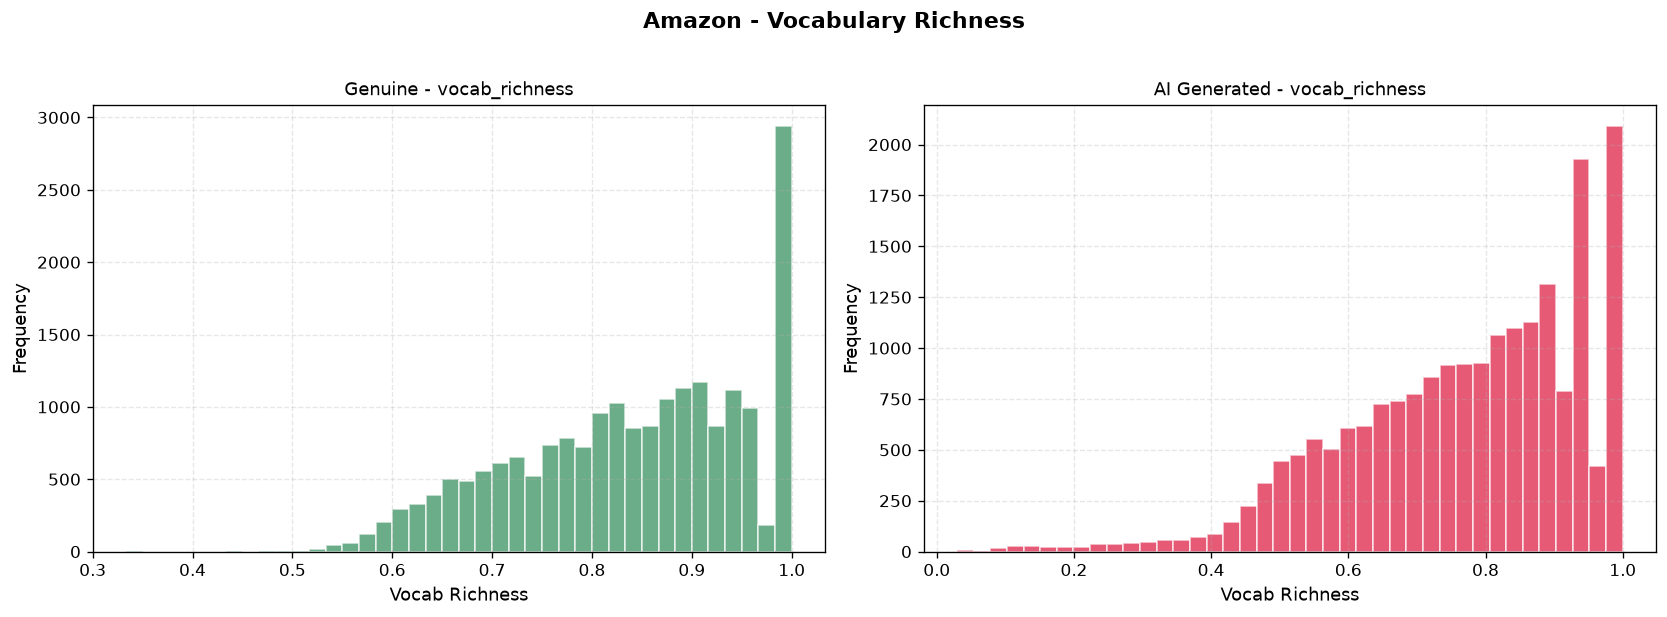

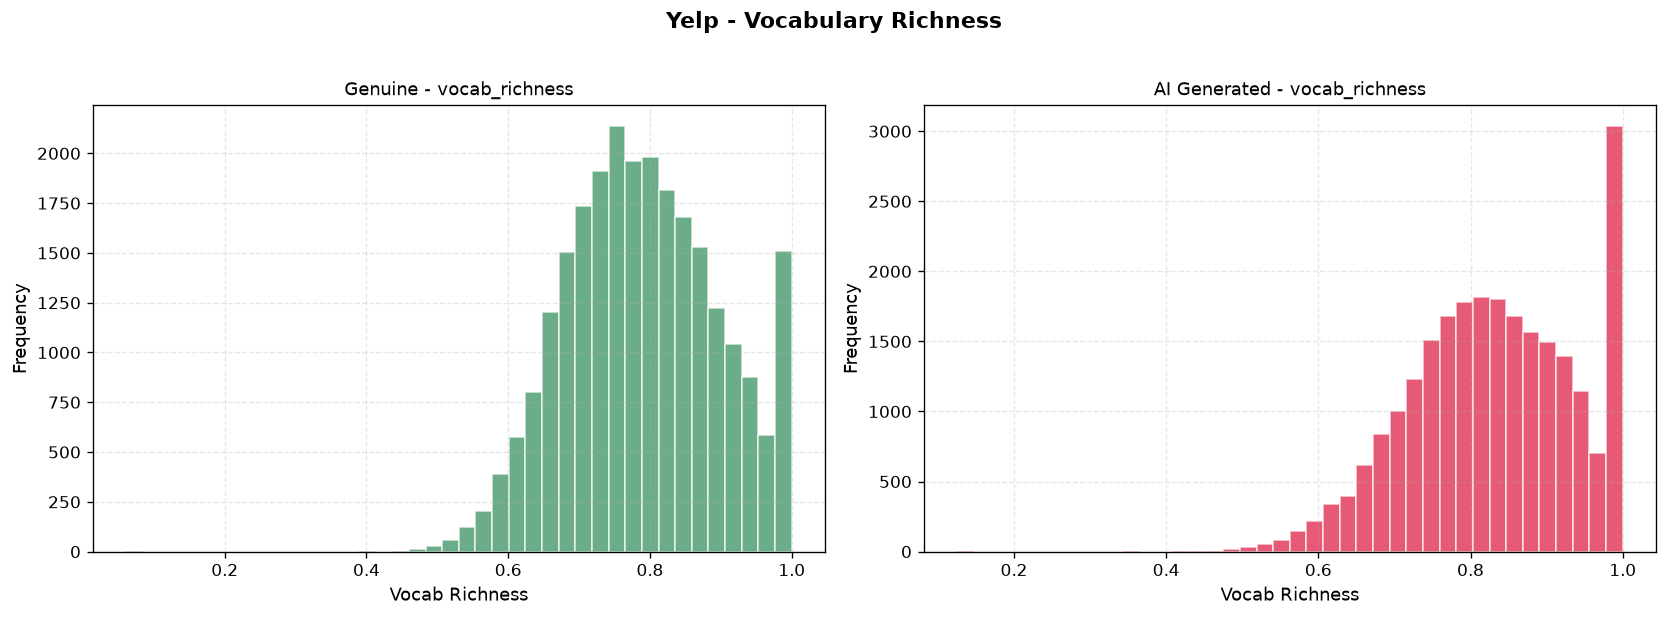

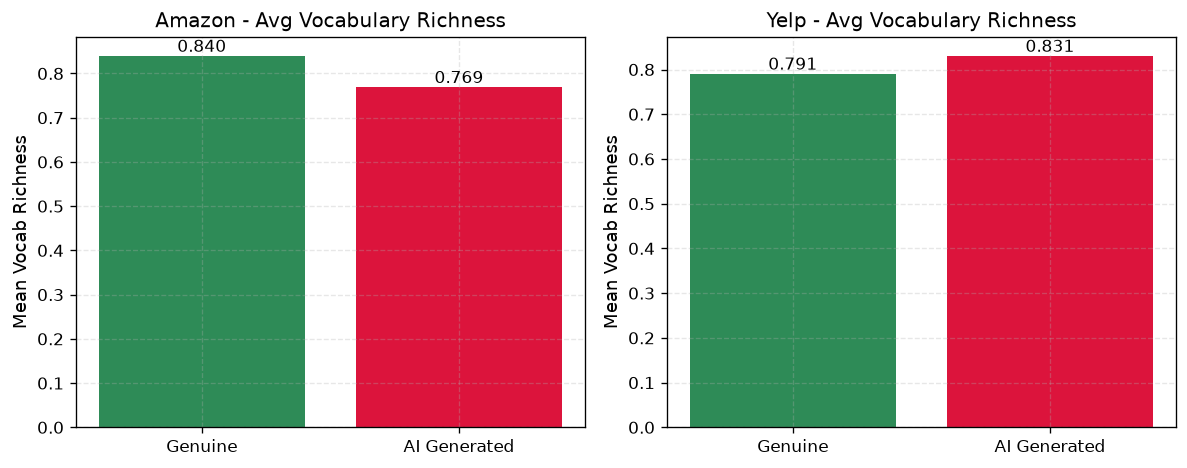

In [10]:
plot_feature_distribution(amazon_df, 'vocab_richness', 'Amazon - Vocabulary Richness')
plot_feature_distribution(yelp_sample, 'vocab_richness', 'Yelp - Vocabulary Richness')

# Summary statistics
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, df, title in zip(axes, [amazon_df, yelp_sample], ['Amazon', 'Yelp']):
    means = df.groupby('label')['vocab_richness'].mean()
    ax.bar(['Genuine', 'AI Generated'], means.values, color=[GENUINE_COLOR, FAKE_COLOR])
    ax.set_title(f'{title} - Avg Vocabulary Richness')
    ax.set_ylabel('Mean Vocab Richness')
    for i, v in enumerate(means.values):
        ax.text(i, v, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Insight to look for:** vocabulary richness behaves **oppositely** across domains — lower for AI reviews on Amazon, higher on Yelp. A model leaning on this feature will struggle to transfer, a textbook case of domain shift.

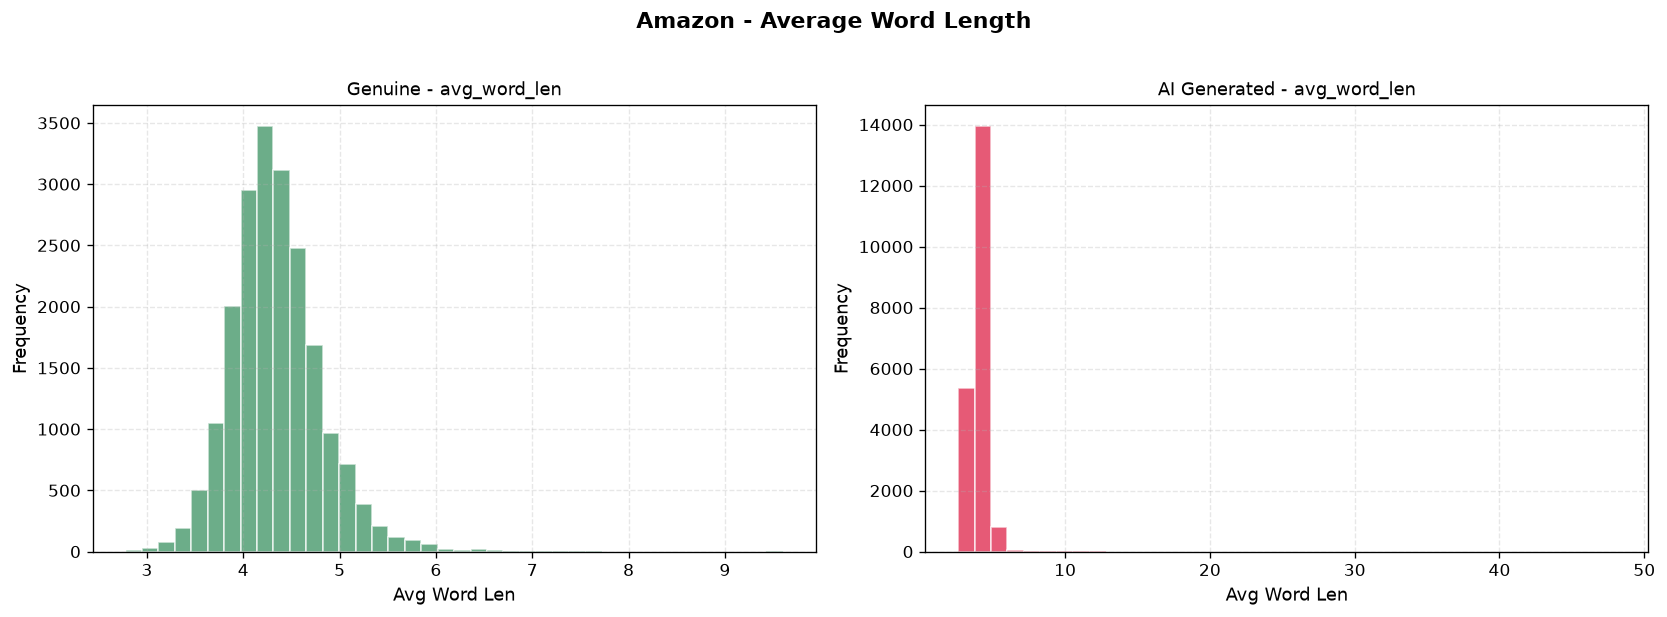

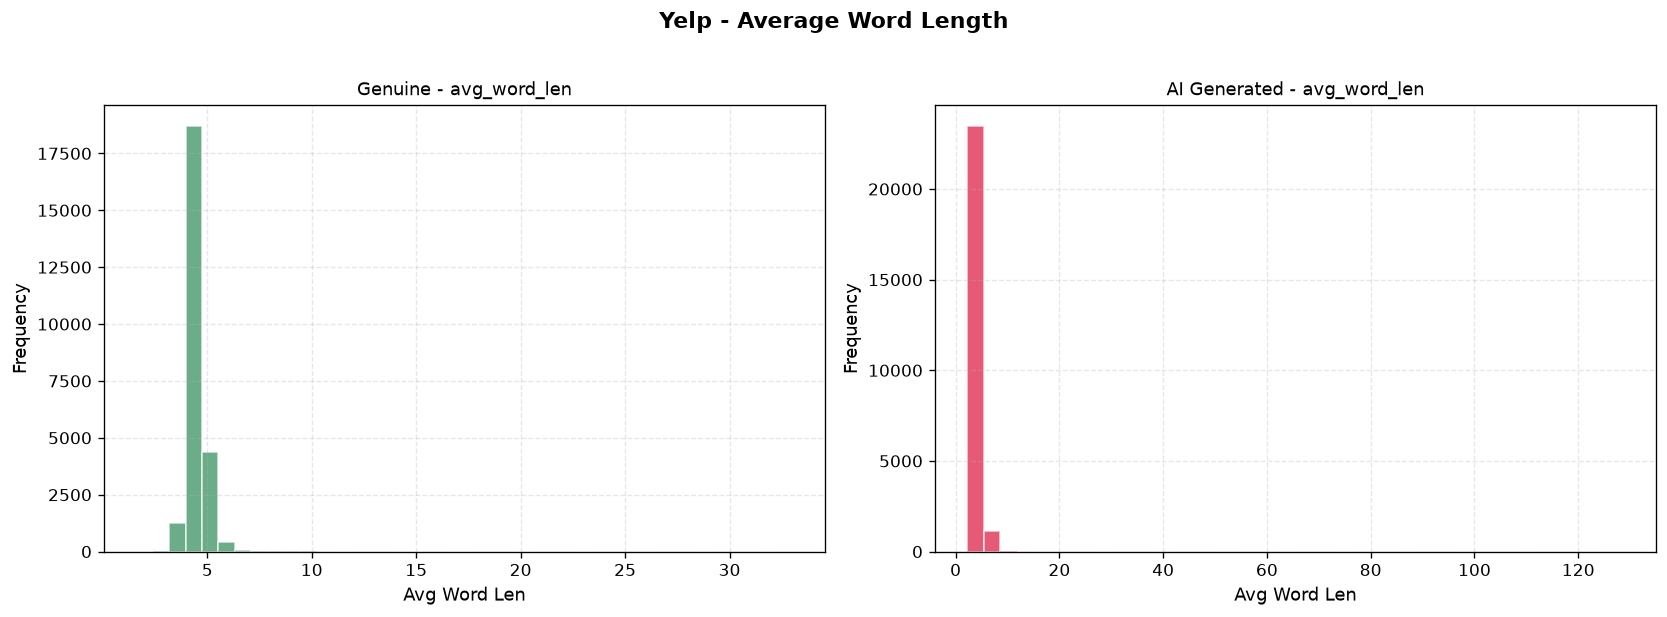

In [11]:
plot_feature_distribution(amazon_df, 'avg_word_len', 'Amazon - Average Word Length')
plot_feature_distribution(yelp_sample, 'avg_word_len', 'Yelp - Average Word Length')

### 4.3 Cross-Domain Feature Comparison

What: side-by-side Amazon/Yelp distributions for all four linguistic features. Why: this single view summarizes the transfer challenge — same features, different scales and class separations.

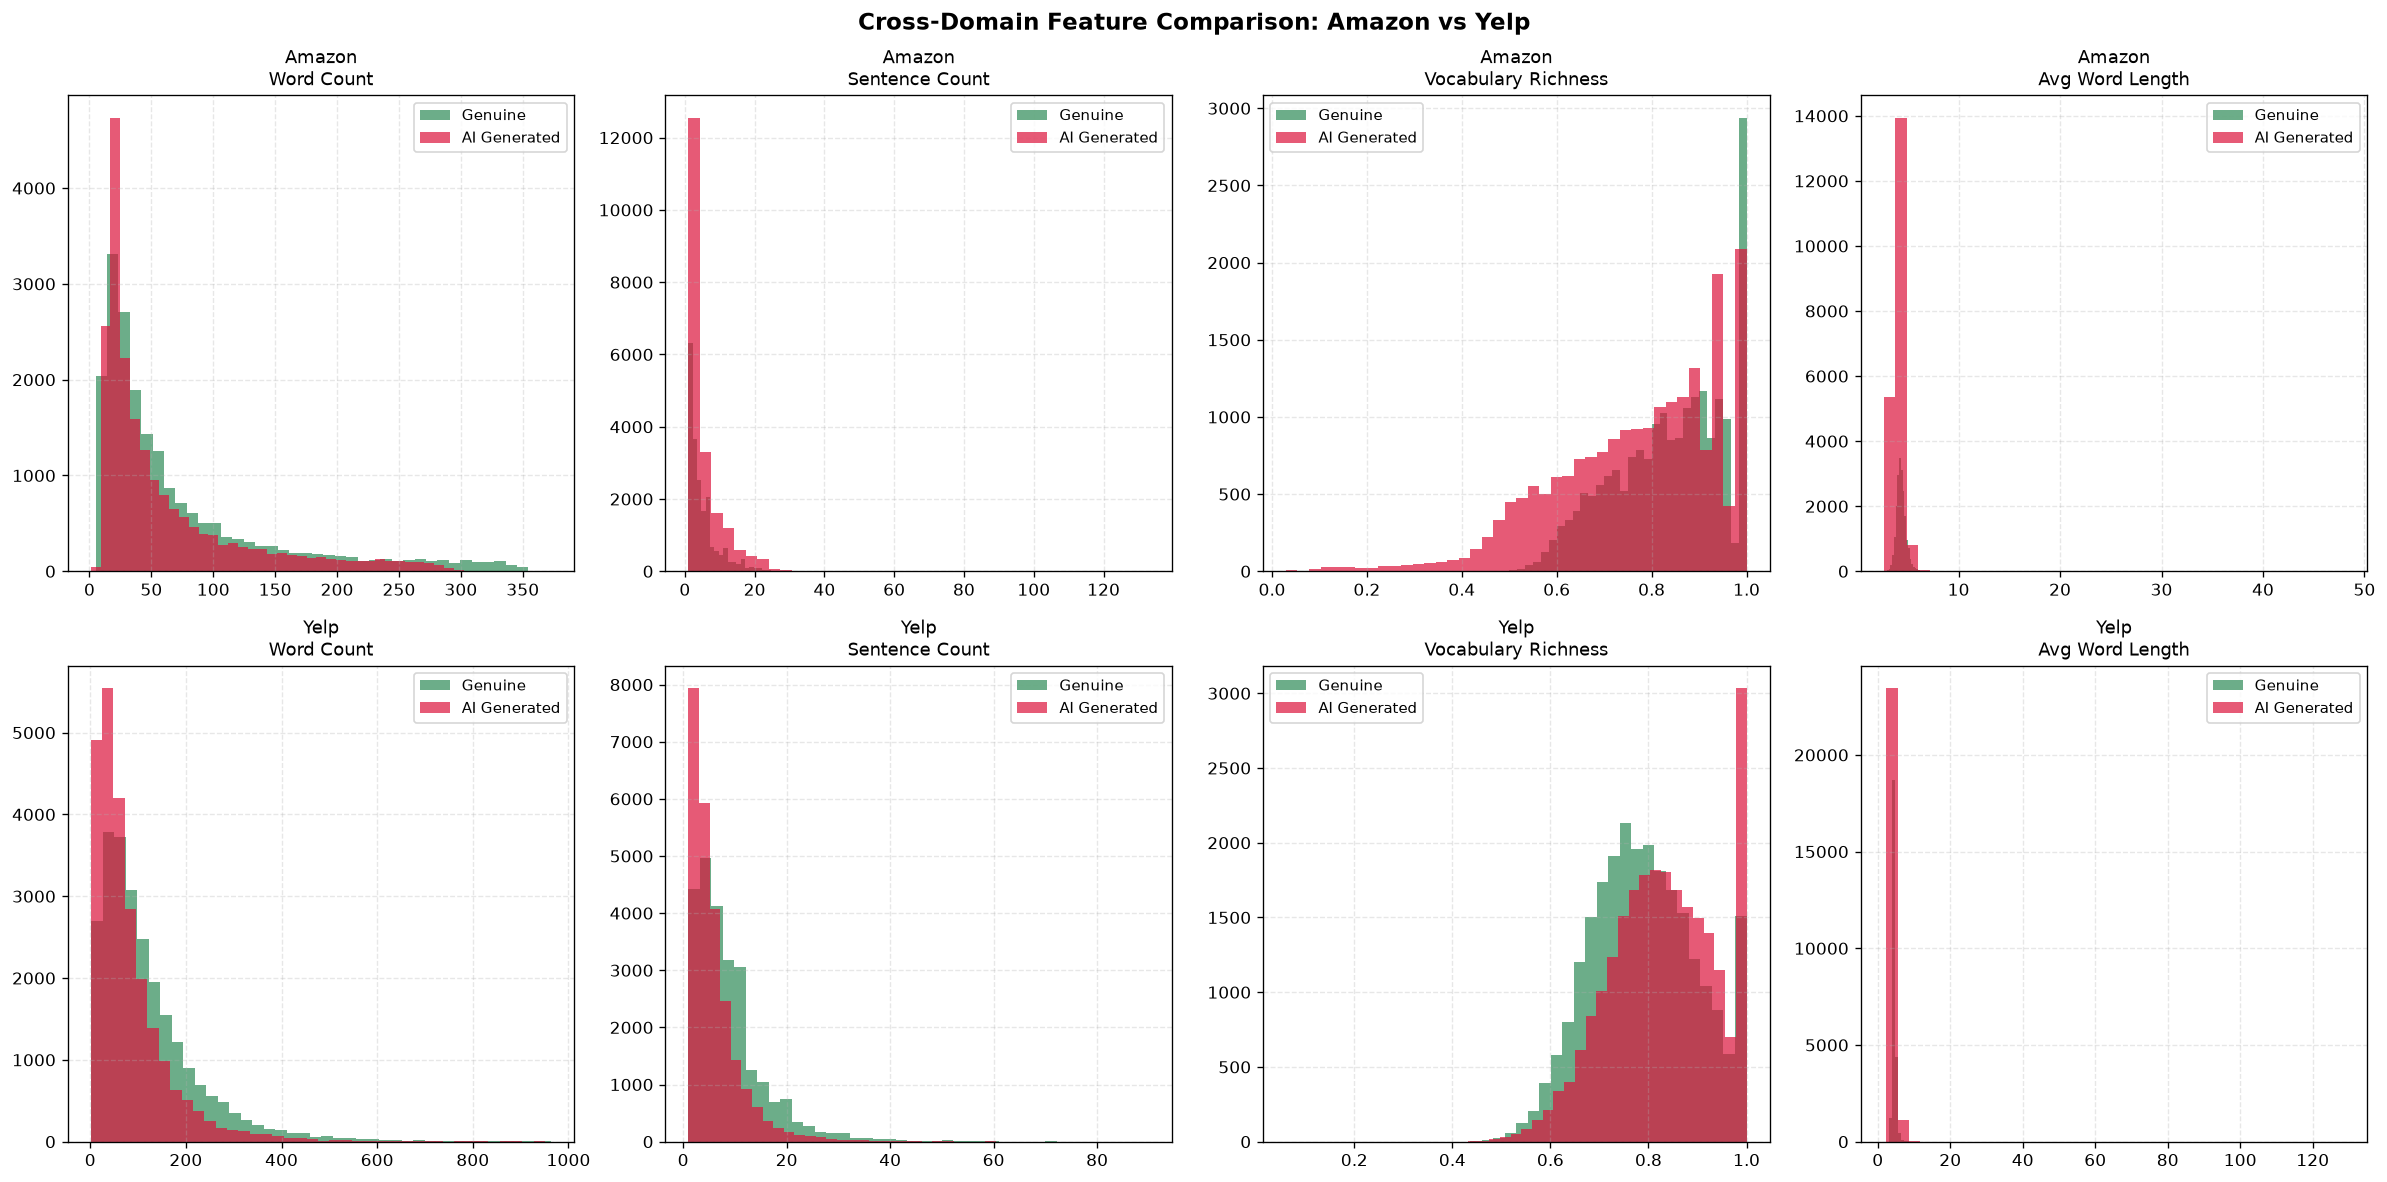

In [12]:
# Cross-domain comparison of feature distributions by label
features_to_compare = ['word_count', 'sentence_count', 'vocab_richness', 'avg_word_len']
feature_labels = ['Word Count', 'Sentence Count', 'Vocabulary Richness', 'Avg Word Length']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for col, (feat, feat_label) in enumerate(zip(features_to_compare, feature_labels)):
    # Amazon genuine
    axes[0, col].hist(amazon_df[amazon_df['label']==0][feat], bins=40, alpha=0.7, color=GENUINE_COLOR, label='Genuine')
    axes[0, col].hist(amazon_df[amazon_df['label']==1][feat], bins=40, alpha=0.7, color=FAKE_COLOR, label='AI Generated')
    axes[0, col].set_title(f'Amazon\n{feat_label}', fontsize=11)
    axes[0, col].legend(fontsize=9)

    # Yelp genuine
    axes[1, col].hist(yelp_sample[yelp_sample['label']==0][feat], bins=40, alpha=0.7, color=GENUINE_COLOR, label='Genuine')
    axes[1, col].hist(yelp_sample[yelp_sample['label']==1][feat], bins=40, alpha=0.7, color=FAKE_COLOR, label='AI Generated')
    axes[1, col].set_title(f'Yelp\n{feat_label}', fontsize=11)
    axes[1, col].legend(fontsize=9)

fig.suptitle('Cross-Domain Feature Comparison: Amazon vs Yelp', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Key takeaways:** Yelp reviews are ~60% longer on average; sentence-count scales differ; average word length is the most stable feature across domains.

### 4.4 Lexical Analysis

What: word clouds, top words/bigrams in AI reviews, and keyword case studies (`characters`, `recommend`). Why: to check whether fake-review vocabulary is domain-specific — if tell-tale words exist only on Amazon, they cannot transfer to Yelp.

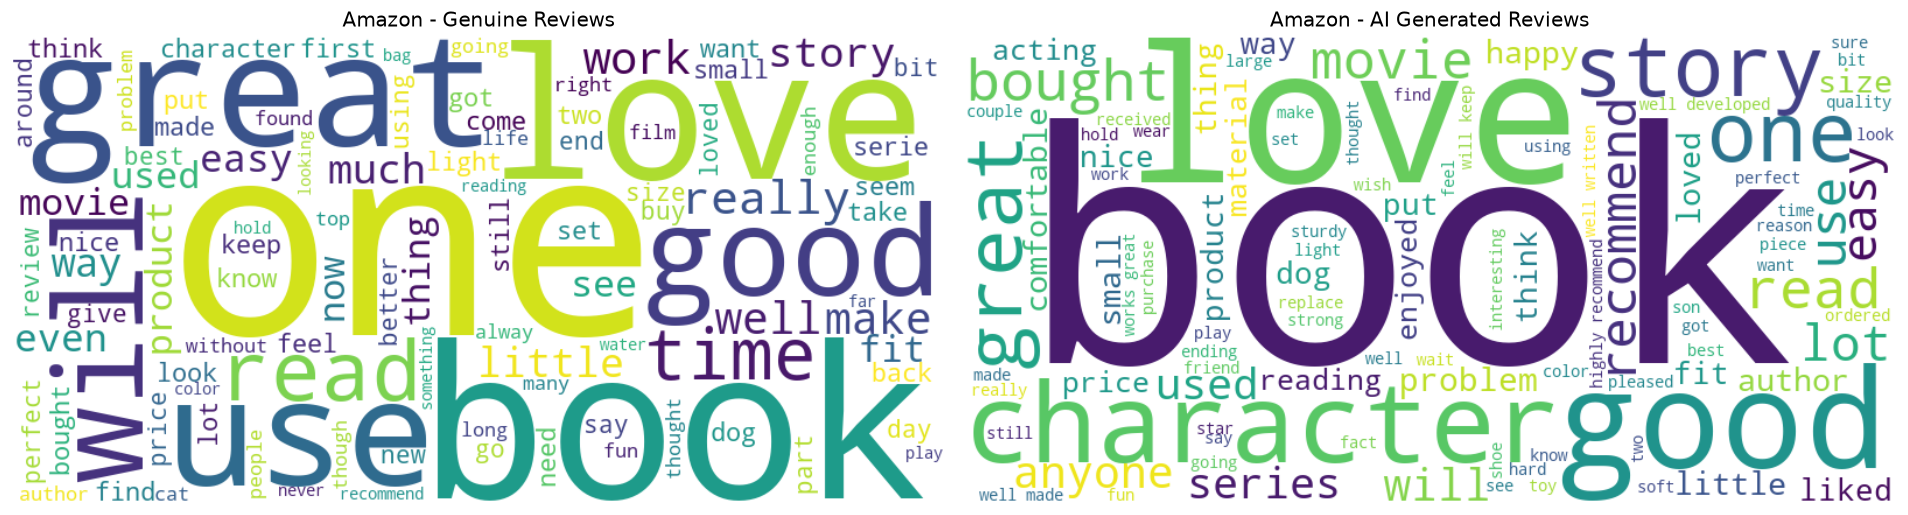

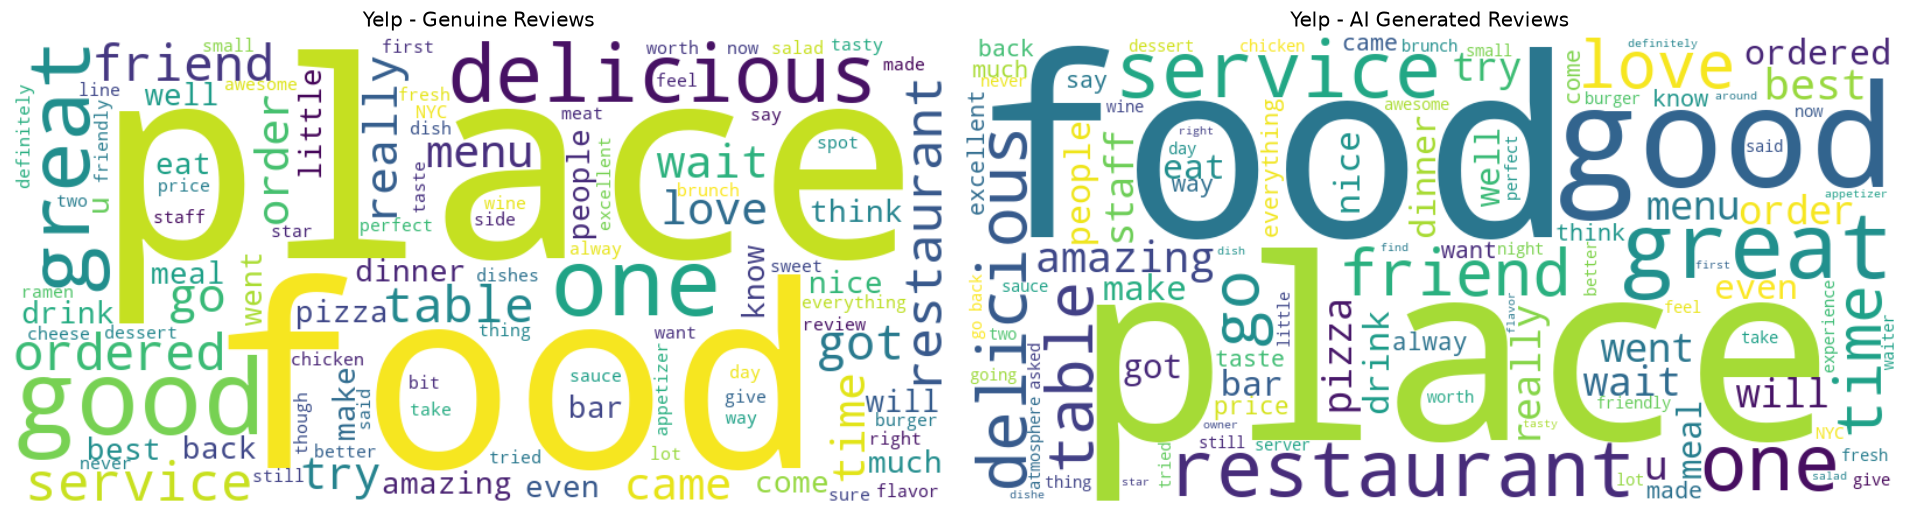

In [13]:
def plot_wordclouds(df, dataset_name):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ax, label, title in zip(axes, [0, 1], ['Genuine', 'AI Generated']):
        text = ' '.join(df[df['label'] == label]['review'])
        wc = WordCloud(width=800, height=400, background_color='white',
                       max_words=100, colormap='viridis').generate(text)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'{dataset_name} - {title} Reviews', fontsize=12)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_wordclouds(amazon_df, 'Amazon')
plot_wordclouds(yelp_sample, 'Yelp')

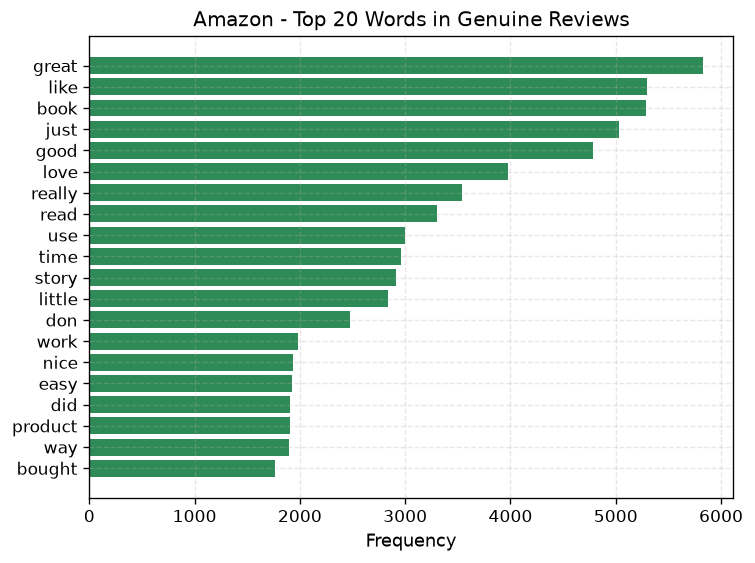

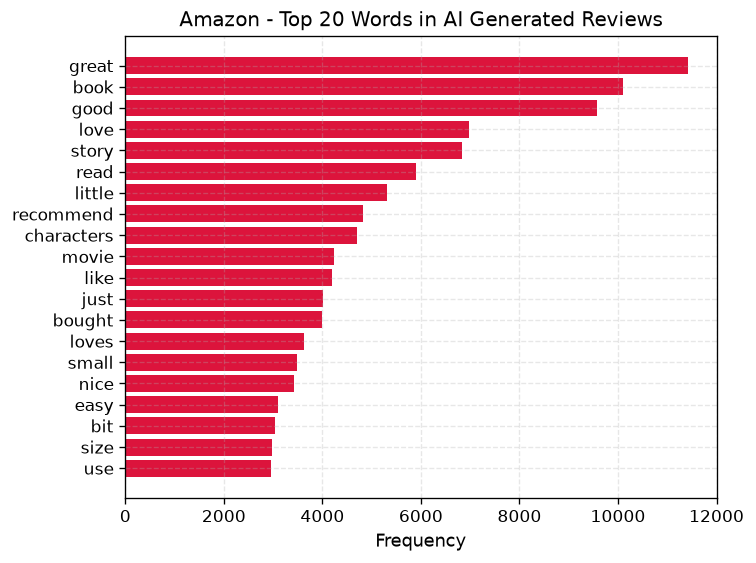

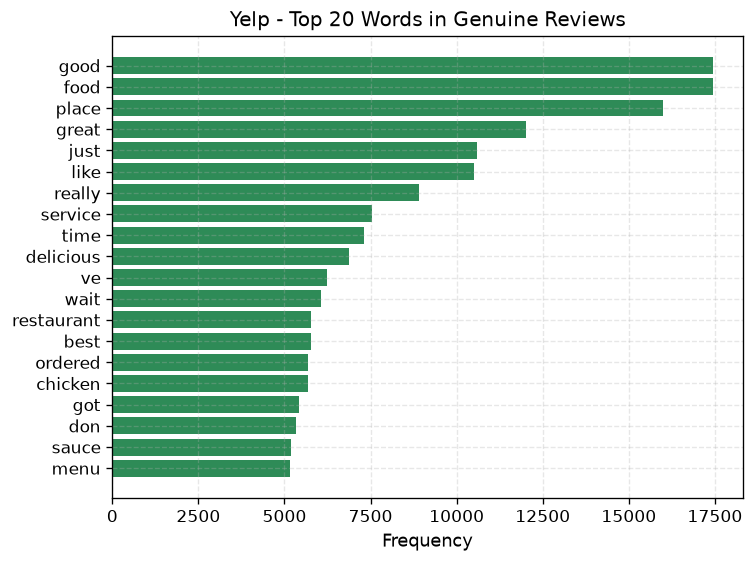

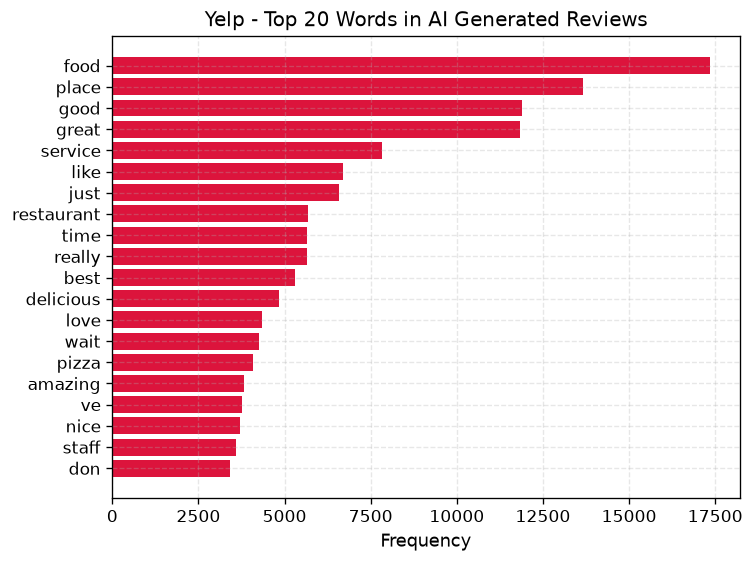

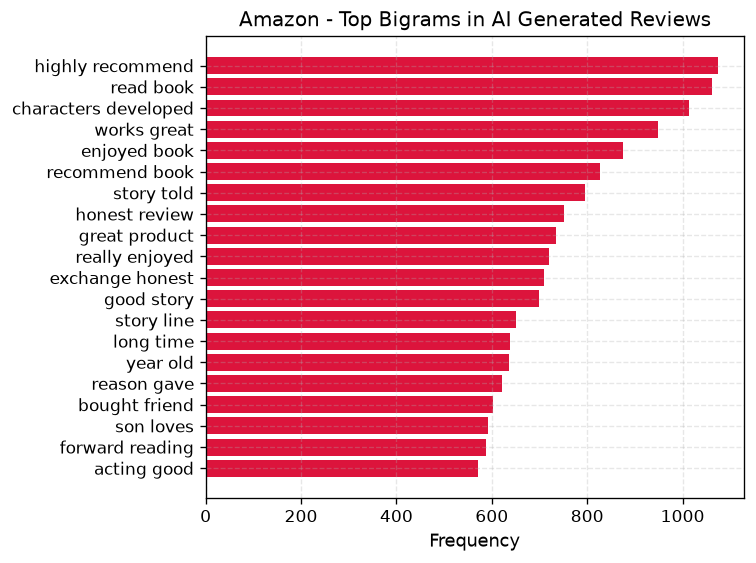

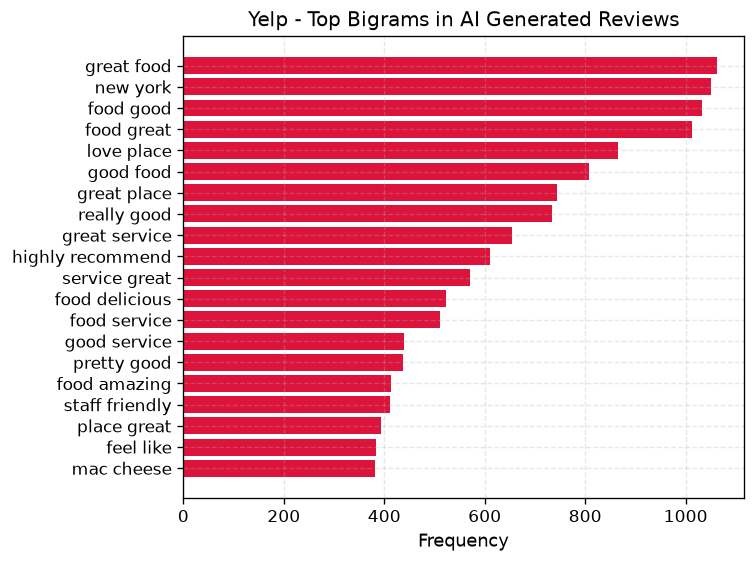

In [14]:
def plot_top_words(dataframe, label, title, n=20):
    vectorizer = CountVectorizer(stop_words='english', max_features=n)
    X = vectorizer.fit_transform(dataframe[dataframe['label'] == label]['review'])
    counts = np.asarray(X.sum(axis=0)).flatten()
    words = vectorizer.get_feature_names_out()
    pairs = sorted(zip(words, counts), key=lambda x: x[1], reverse=True)
    words, counts = zip(*pairs)
    plt.barh(words, counts, color=GENUINE_COLOR if label == 0 else FAKE_COLOR)
    plt.title(title)
    plt.xlabel('Frequency')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_top_words(amazon_df, 0, 'Amazon - Top 20 Words in Genuine Reviews')
plot_top_words(amazon_df, 1, 'Amazon - Top 20 Words in AI Generated Reviews')

plot_top_words(yelp_sample, 0, 'Yelp - Top 20 Words in Genuine Reviews')
plot_top_words(yelp_sample, 1, 'Yelp - Top 20 Words in AI Generated Reviews')

def plot_top_bigrams(dataframe, title, n=20):
    vectorizer = CountVectorizer(stop_words='english', ngram_range=(2, 2), max_features=n)
    X = vectorizer.fit_transform(dataframe[dataframe['label'] == 1]['review'])
    counts = np.asarray(X.sum(axis=0)).flatten()
    bigrams = vectorizer.get_feature_names_out()
    pairs = sorted(zip(bigrams, counts), key=lambda x: x[1], reverse=True)
    bigrams, counts = zip(*pairs)
    plt.barh(bigrams, counts, color=FAKE_COLOR)
    plt.title(title)
    plt.xlabel('Frequency')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_top_bigrams(amazon_df, 'Amazon - Top Bigrams in AI Generated Reviews')
plot_top_bigrams(yelp_sample, 'Yelp - Top Bigrams in AI Generated Reviews')

In [15]:
for word in ['characters', 'recommend']:
    subset = amazon_df[amazon_df['review'].str.contains(rf'\b{word}\b', case=False, na=False)]
    label_counts = subset['label'].value_counts().sort_index()
    print(f'\nWord: "{word}" in Amazon')
    print(f'  Total occurrences: {len(subset)}')
    if len(subset) > 0:
        pct = (label_counts / len(subset) * 100).round(2)
        for lbl in label_counts.index:
            name = 'Genuine' if lbl == 0 else 'AI Generated'
            print(f'  {name}: {label_counts[lbl]:,} ({pct[lbl]:.1f}%)')


Word: "characters" in Amazon
  Total occurrences: 3697
  Genuine: 1,130 (30.6%)
  AI Generated: 2,567 (69.4%)

Word: "recommend" in Amazon
  Total occurrences: 4797
  Genuine: 1,373 (28.6%)
  AI Generated: 3,424 (71.4%)


**Transfer implication:** keywords concentrated in Amazon AI reviews are weak transfer features unless the same patterns appear in Yelp.

### 4.5 Correlation Analysis

What: per-domain correlation matrices of linguistic features. Why: differing correlation structures confirm that identical features carry different predictive weight per domain.

C:\Users\venom\AppData\Local\Temp\ipykernel_24564\1800651866.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


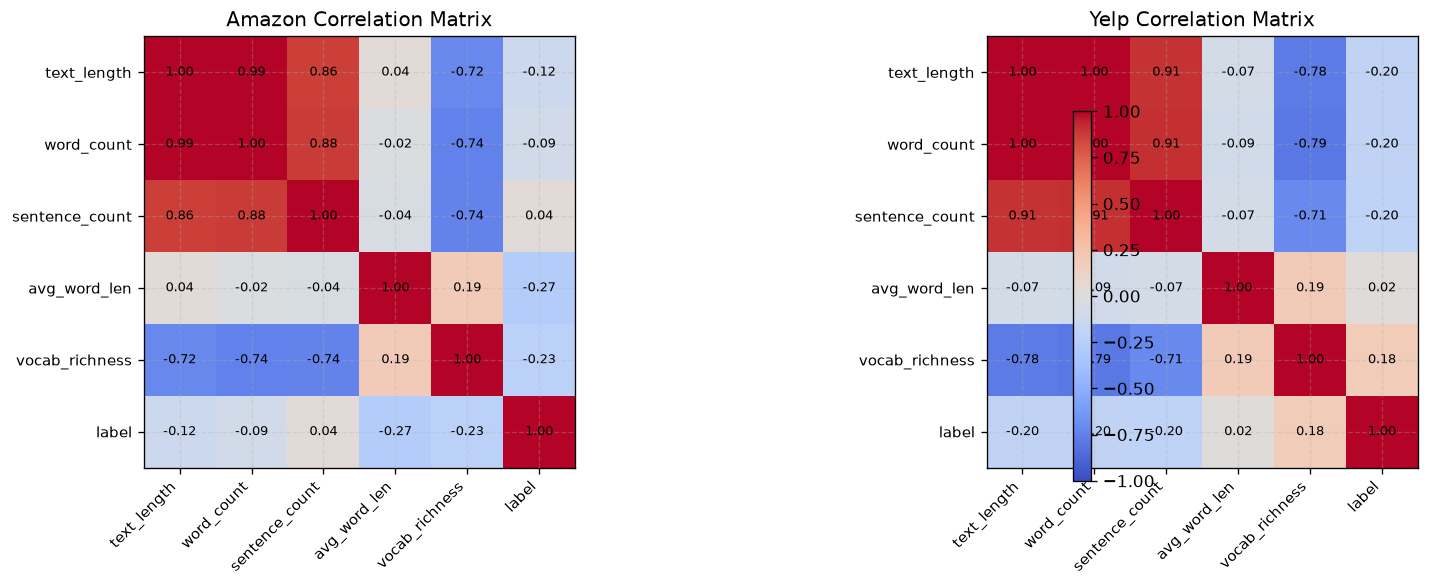

In [16]:
feature_cols = ['text_length', 'word_count', 'sentence_count', 'avg_word_len', 'vocab_richness', 'label']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, [amazon_df, yelp_sample], ['Amazon', 'Yelp']):
    corr = df[feature_cols].corr()
    im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(feature_cols)))
    ax.set_yticks(range(len(feature_cols)))
    ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(feature_cols, fontsize=9)
    ax.set_title(f'{title} Correlation Matrix', fontsize=12)
    # Add correlation values
    for i in range(len(feature_cols)):
        for j in range(len(feature_cols)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.tight_layout()
plt.show()

### 4.6 Metadata (Style) Features

Additional style statistics that capture writing habits:

| Feature | Description |
|---------|-------------|
| `punctuation_count` | Punctuation density |
| `uppercase_ratio` | Share of uppercase characters |
| `digit_count` | Numeric content |
| `avg_sentence_length` | Words per sentence |
| `low_vocab_richness` | Binary flag: vocabulary richness below 0.40 |

What: the next cells engineer these features and run data-quality checks. Why: style markers are often more domain-robust than raw vocabulary.

In [17]:
VOCAB_THRESHOLD = 0.40

def punctuation_count(review):
    return sum(char in string.punctuation for char in review)

def uppercase_ratio(review):
    if len(review) == 0:
        return 0
    return sum(char.isupper() for char in review) / len(review)

def digit_count(review):
    return sum(char.isdigit() for char in review)

def avg_sentence_length(review):
    sentences = [s for s in review.replace('!', '.').replace('?', '.').split('.') if s.strip()]
    if len(sentences) == 0:
        return 0
    return np.mean([len(sentence.split()) for sentence in sentences])

def engineer_metadata(dataset):
    dataset = dataset.copy()
    dataset['punctuation_count'] = dataset['review'].apply(punctuation_count)
    dataset['uppercase_ratio'] = dataset['review'].apply(uppercase_ratio)
    dataset['digit_count'] = dataset['review'].apply(digit_count)
    dataset['avg_sentence_length'] = dataset['review'].apply(avg_sentence_length)
    dataset['low_vocab_richness'] = (dataset['vocab_richness'] < VOCAB_THRESHOLD).astype(int)
    return dataset

amazon_df = engineer_metadata(amazon_df)
yelp_sample = engineer_metadata(yelp_sample)

metadata_columns = [
    'text_length', 'word_count', 'sentence_count', 'avg_word_len',
    'vocab_richness', 'low_vocab_richness',
    'punctuation_count', 'uppercase_ratio', 'digit_count', 'avg_sentence_length'
]

print('Metadata features engineered for both datasets.')
print(f'Feature columns ({len(metadata_columns)}): {metadata_columns}')

Metadata features engineered for both datasets.
Feature columns (10): ['text_length', 'word_count', 'sentence_count', 'avg_word_len', 'vocab_richness', 'low_vocab_richness', 'punctuation_count', 'uppercase_ratio', 'digit_count', 'avg_sentence_length']


In [18]:
print('Amazon Missing Values:')
print(amazon_df[metadata_columns].isnull().sum().to_string())
print()
print('Yelp Missing Values:')
print(yelp_sample[metadata_columns].isnull().sum().to_string())

print('Amazon Feature Statistics:')
print(amazon_df[metadata_columns].describe().T.to_string())
print()
print('Yelp Feature Statistics:')
print(yelp_sample[metadata_columns].describe().T.to_string())

def vocab_threshold_analysis(dataset, name):
    summary = (
        dataset.groupby('label')['low_vocab_richness']
        .agg(['sum', 'count', 'mean'])
        .rename(columns={'sum': 'Below Threshold', 'count': 'Total Reviews', 'mean': 'Pct Below'})
    )
    summary['Pct Below'] = (summary['Pct Below'] * 100).round(2)
    print(f'\n{name} Dataset - Vocabulary Threshold Analysis (threshold={VOCAB_THRESHOLD}):')
    print(summary.to_string())

vocab_threshold_analysis(amazon_df, 'Amazon')
vocab_threshold_analysis(yelp_sample, 'Yelp')

Amazon Missing Values:
text_length            0
word_count             0
sentence_count         0
avg_word_len           0
vocab_richness         0
low_vocab_richness     0
punctuation_count      0
uppercase_ratio        0
digit_count            0
avg_sentence_length    0

Yelp Missing Values:
text_length            0
word_count             0
sentence_count         0
avg_word_len           0
vocab_richness         0
low_vocab_richness     0
punctuation_count      0
uppercase_ratio        0
digit_count            0
avg_sentence_length    0
Amazon Feature Statistics:
                       count        mean         std        min         25%         50%         75%          max
text_length          40408.0  348.048604  365.157114  28.000000  106.000000  197.000000  435.000000  2164.000000
word_count           40408.0   67.455454   69.565885   1.000000   21.000000   39.000000   85.000000   373.000000
sentence_count       40408.0    5.273683    4.913880   1.000000    2.000000    3.000000  

## 5. Transfer Learning Methodology

### 5.1 Transfer Paradigm

| Direction | Train (source) | Test (target) | Purpose |
|-----------|----------------|---------------|---------|
| **Experiment A: Amazon → Yelp** | Amazon reviews | Yelp reviews | Product-to-service transfer |
| **Experiment B: Yelp → Amazon** | Yelp reviews | Amazon reviews | Service-to-product transfer |

### 5.2 Data-Leakage Prevention

Validity hinges on fitting all transformations on the **source domain only**:

1. TF-IDF vocabulary is fit on source reviews; target reviews are only transformed.
2. `StandardScaler` is fit on source metadata; target metadata is only transformed.
3. The target test set is never seen during training.

### 5.3 Training Protocol

For each direction: train 4 classifiers → evaluate 5 metrics on the target domain → compare directions (Section 8) → test few-shot adaptation (Section 9).

What: the next three cells build the feature matrices. Why: separating matrix construction from model training makes the leakage guarantees explicit and auditable.

In [19]:
X_amazon_metadata = amazon_df[metadata_columns].copy()
y_amazon = amazon_df['label'].copy()

X_yelp_metadata = yelp_sample[metadata_columns].copy()
y_yelp = yelp_sample['label'].copy()

X_amazon_text = amazon_df['review'].copy()
X_yelp_text = yelp_sample['review'].copy()

print('Amazon Metadata Shape:', X_amazon_metadata.shape)
print('Yelp Metadata Shape:', X_yelp_metadata.shape)
print('Amazon Reviews:', len(X_amazon_text))
print('Yelp Reviews:', len(X_yelp_text))

Amazon Metadata Shape: (40408, 10)
Yelp Metadata Shape: (49506, 10)
Amazon Reviews: 40408
Yelp Reviews: 49506


In [20]:
# TF-IDF fitted ONLY on Amazon reviews
tfidf_amazon = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2, stop_words='english')
X_amazon_tfidf = tfidf_amazon.fit_transform(X_amazon_text)
X_yelp_tfidf = tfidf_amazon.transform(X_yelp_text)

# Metadata scaler fitted ONLY on Amazon metadata
scaler_amazon = StandardScaler()
X_amazon_meta_scaled = scaler_amazon.fit_transform(X_amazon_metadata)
X_yelp_meta_scaled = scaler_amazon.transform(X_yelp_metadata)

# Combine
X_train_A = hstack([X_amazon_tfidf, X_amazon_meta_scaled])
X_test_A = hstack([X_yelp_tfidf, X_yelp_meta_scaled])
y_train_A = y_amazon
y_test_A = y_yelp

print('Experiment A:')
print(f'  Training (Amazon): {X_train_A.shape}')
print(f'  Testing (Yelp):    {X_test_A.shape}')

Experiment A:
  Training (Amazon): (40408, 15010)
  Testing (Yelp):    (49506, 15010)


In [21]:
# TF-IDF fitted ONLY on Yelp reviews
tfidf_yelp = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2, stop_words='english')
X_yelp_tfidf = tfidf_yelp.fit_transform(X_yelp_text)
X_amazon_tfidf = tfidf_yelp.transform(X_amazon_text)

# Metadata scaler fitted ONLY on Yelp metadata
scaler_yelp = StandardScaler()
X_yelp_meta_scaled = scaler_yelp.fit_transform(X_yelp_metadata)
X_amazon_meta_scaled = scaler_yelp.transform(X_amazon_metadata)

# Combine
X_train_B = hstack([X_yelp_tfidf, X_yelp_meta_scaled])
X_test_B = hstack([X_amazon_tfidf, X_amazon_meta_scaled])
y_train_B = y_yelp
y_test_B = y_amazon

print('Experiment B:')
print(f'  Training (Yelp):    {X_train_B.shape}')
print(f'  Testing (Amazon):   {X_test_B.shape}')

Experiment B:
  Training (Yelp):    (49506, 15010)
  Testing (Amazon):   (40408, 15010)


## 6. Model Training

### 6.1 Algorithm Selection

| Algorithm | Type | Rationale |
|-----------|------|-----------|
| Logistic Regression | Linear | Fast, interpretable baseline |
| Linear SVM | Linear | Strong on high-dimensional sparse text |
| Random Forest | Ensemble | Captures feature interactions |
| XGBoost | Boosted trees | Typically strongest tabular/text-hybrid performance |

Shared settings: `max_iter=300`, `random_state=42`, parallel trees (`n_jobs=-1`).

What: define one shared `train_and_evaluate` helper plus the model zoo. Why: identical training/evaluation code per model keeps the comparison fair.

In [22]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_test)
    else:
        y_score = y_pred

    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_score),
    }

    print(f'\n{"=" * 60}')
    print(model_name)
    print('=' * 60)
    print(classification_report(y_test, y_pred, target_names=['Genuine', 'Fake']))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Genuine', 'Fake'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()

    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title(f'{model_name} - ROC Curve')
    plt.show()

    return results

models = {
    'Logistic Regression': LogisticRegression(max_iter=300, random_state=42),
    'Linear SVM': LinearSVC(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'),
}

What: train all four models per transfer direction. Why: running both directions under one protocol isolates the effect of transfer direction from modeling choices.


Logistic Regression (Amazon -> Yelp)
              precision    recall  f1-score   support

     Genuine       0.51      0.98      0.67     24897
        Fake       0.68      0.03      0.07     24609

    accuracy                           0.51     49506
   macro avg       0.59      0.51      0.37     49506
weighted avg       0.59      0.51      0.37     49506



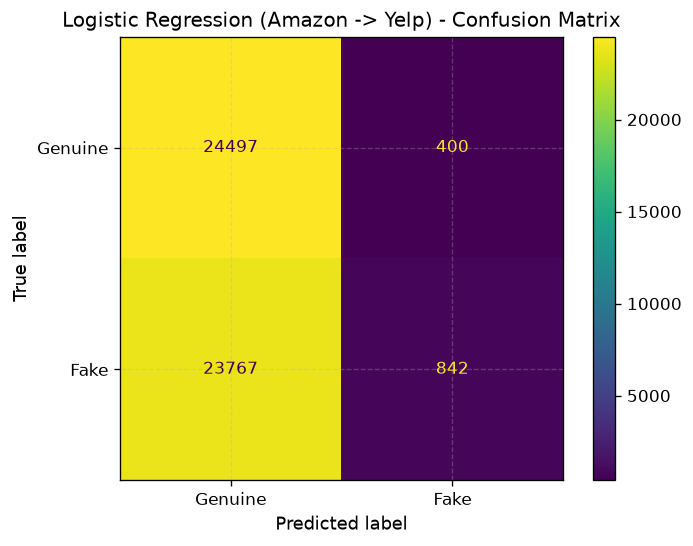

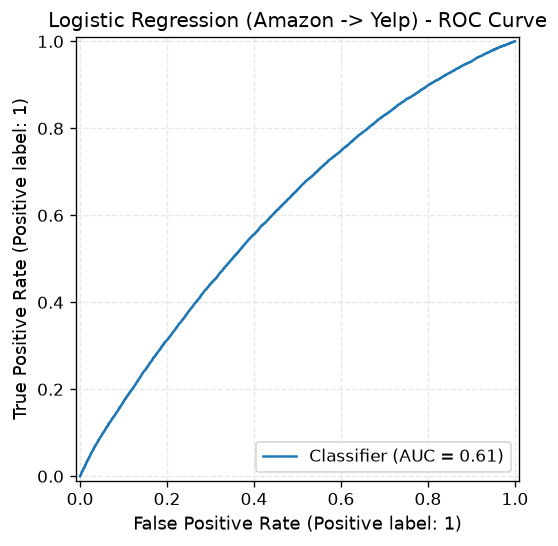


Linear SVM (Amazon -> Yelp)
              precision    recall  f1-score   support

     Genuine       0.51      0.98      0.67     24897
        Fake       0.66      0.04      0.08     24609

    accuracy                           0.51     49506
   macro avg       0.58      0.51      0.37     49506
weighted avg       0.58      0.51      0.38     49506



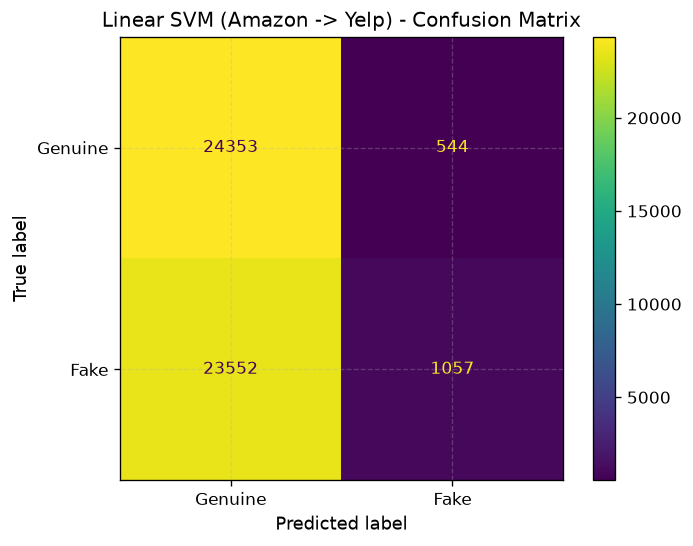

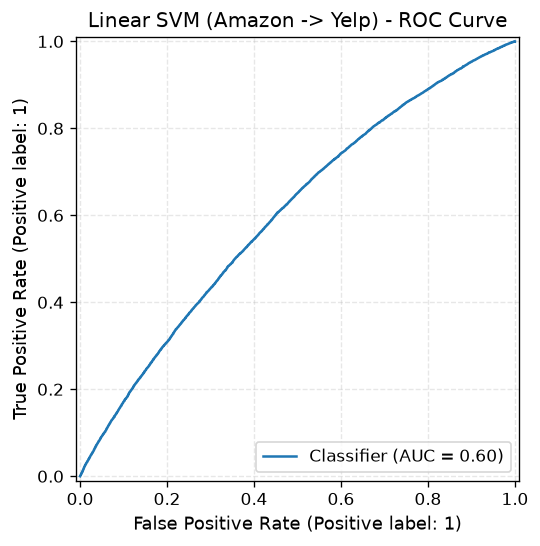


Random Forest (Amazon -> Yelp)
              precision    recall  f1-score   support

     Genuine       0.51      0.99      0.67     24897
        Fake       0.68      0.03      0.06     24609

    accuracy                           0.51     49506
   macro avg       0.59      0.51      0.36     49506
weighted avg       0.59      0.51      0.36     49506



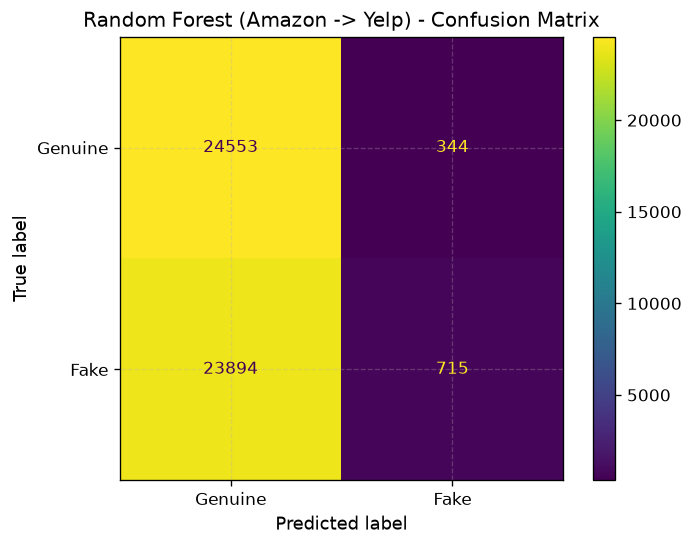

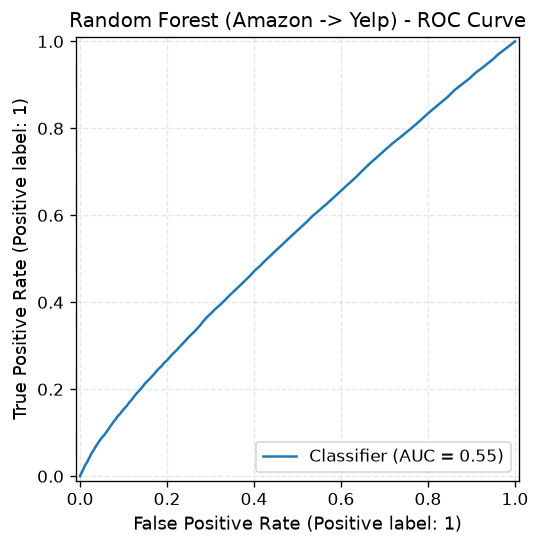


XGBoost (Amazon -> Yelp)
              precision    recall  f1-score   support

     Genuine       0.51      0.98      0.67     24897
        Fake       0.66      0.04      0.07     24609

    accuracy                           0.51     49506
   macro avg       0.58      0.51      0.37     49506
weighted avg       0.58      0.51      0.37     49506



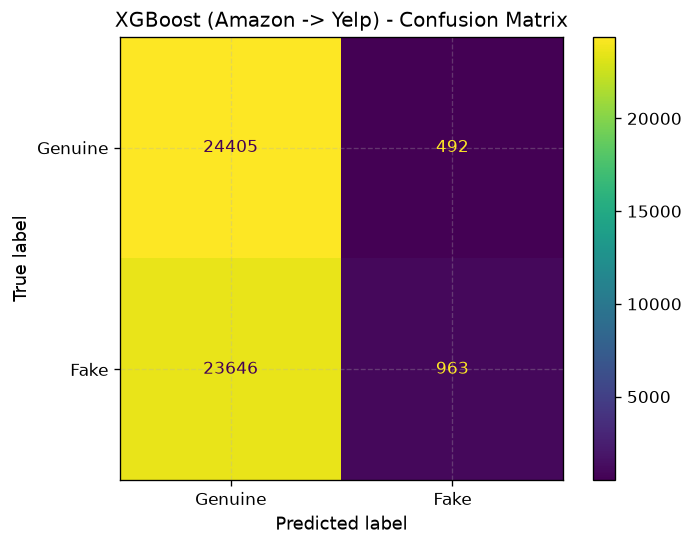

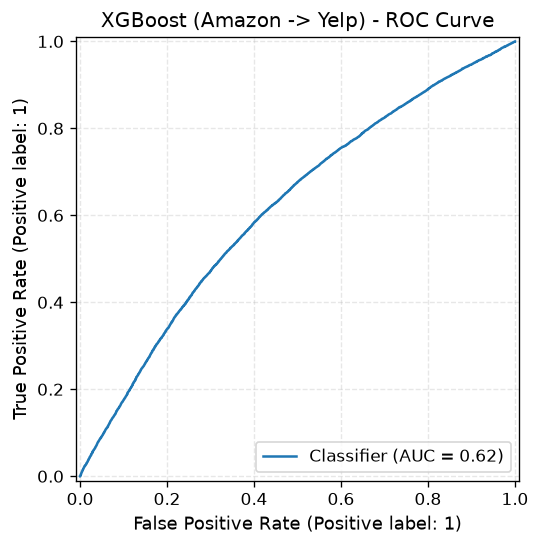

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Amazon -> Yelp),0.511837,0.677939,0.034215,0.065143,0.609076
1,Linear SVM (Amazon -> Yelp),0.513271,0.660212,0.042952,0.080656,0.603365
2,Random Forest (Amazon -> Yelp),0.510403,0.675165,0.029054,0.055711,0.549980
3,XGBoost (Amazon -> Yelp),0.512423,0.661856,0.039132,0.073895,0.617333


In [23]:
results_A = []
for name, model in models.items():
    metrics = train_and_evaluate(model, X_train_A, y_train_A, X_test_A, y_test_A, f'{name} (Amazon -> Yelp)')
    results_A.append(metrics)
results_A = pd.DataFrame(results_A)
results_A


Logistic Regression (Yelp -> Amazon)
              precision    recall  f1-score   support

     Genuine       0.56      0.30      0.39     20215
        Fake       0.52      0.77      0.62     20193

    accuracy                           0.53     40408
   macro avg       0.54      0.53      0.51     40408
weighted avg       0.54      0.53      0.51     40408



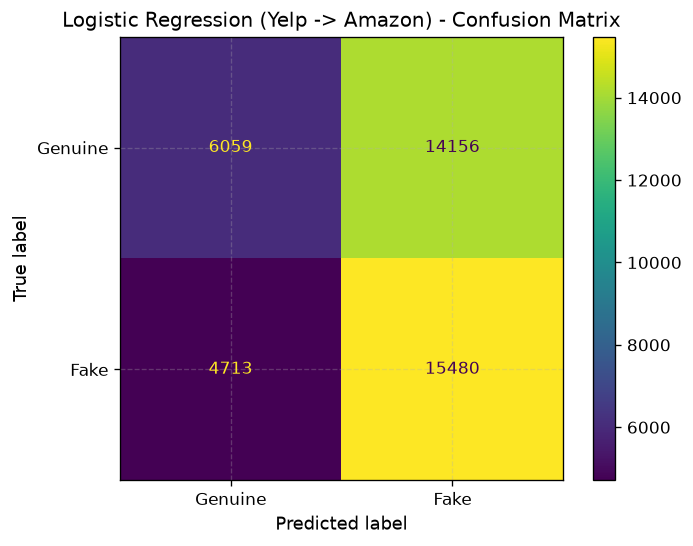

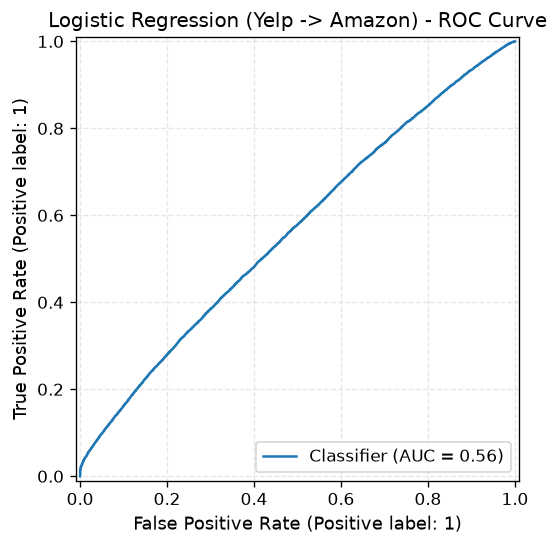


Linear SVM (Yelp -> Amazon)
              precision    recall  f1-score   support

     Genuine       0.56      0.37      0.45     20215
        Fake       0.53      0.70      0.60     20193

    accuracy                           0.54     40408
   macro avg       0.54      0.54      0.52     40408
weighted avg       0.54      0.54      0.52     40408



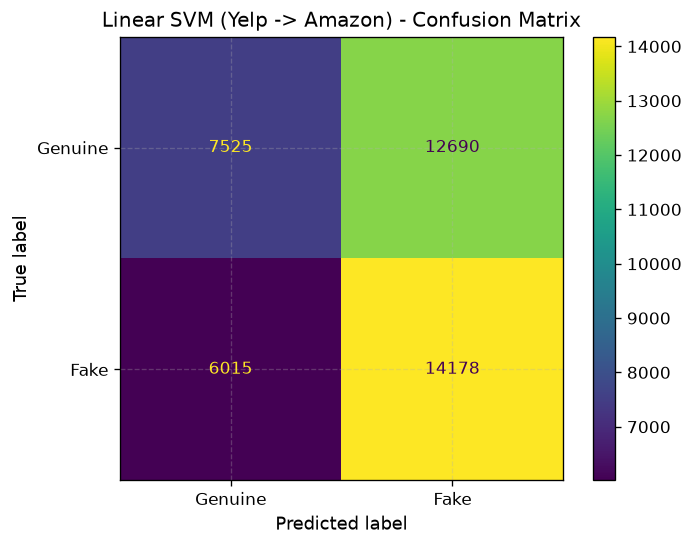

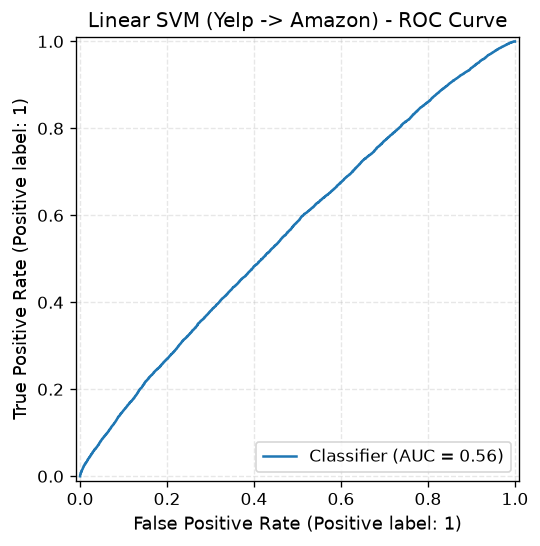


Random Forest (Yelp -> Amazon)
              precision    recall  f1-score   support

     Genuine       0.58      0.27      0.36     20215
        Fake       0.52      0.81      0.63     20193

    accuracy                           0.54     40408
   macro avg       0.55      0.54      0.50     40408
weighted avg       0.55      0.54      0.50     40408



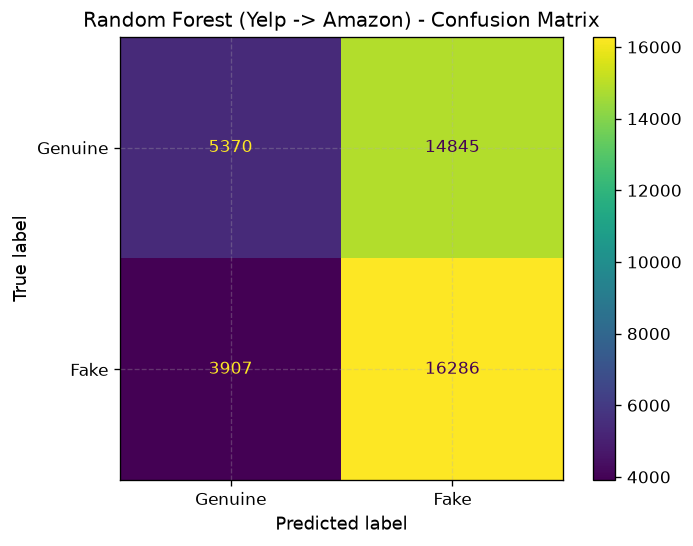

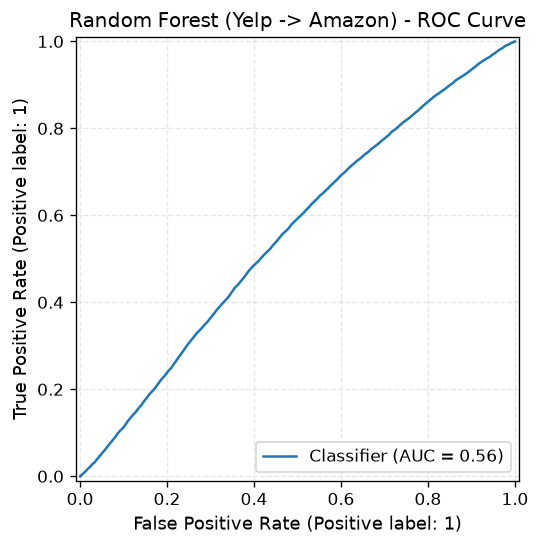


XGBoost (Yelp -> Amazon)
              precision    recall  f1-score   support

     Genuine       0.59      0.30      0.40     20215
        Fake       0.53      0.79      0.63     20193

    accuracy                           0.55     40408
   macro avg       0.56      0.55      0.52     40408
weighted avg       0.56      0.55      0.52     40408



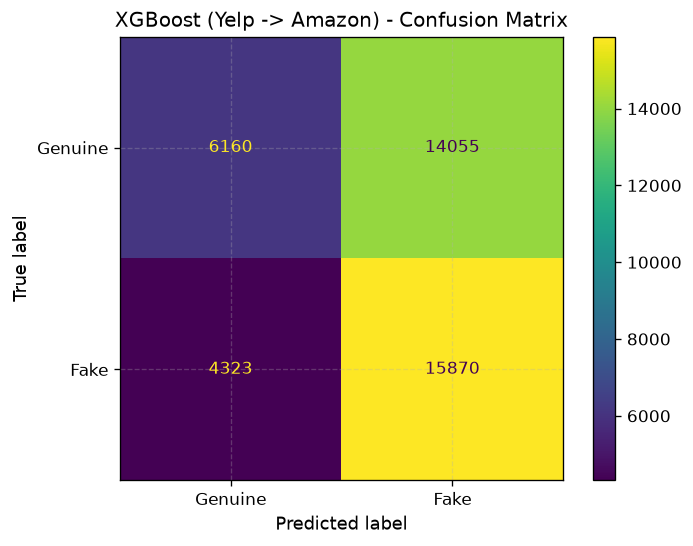

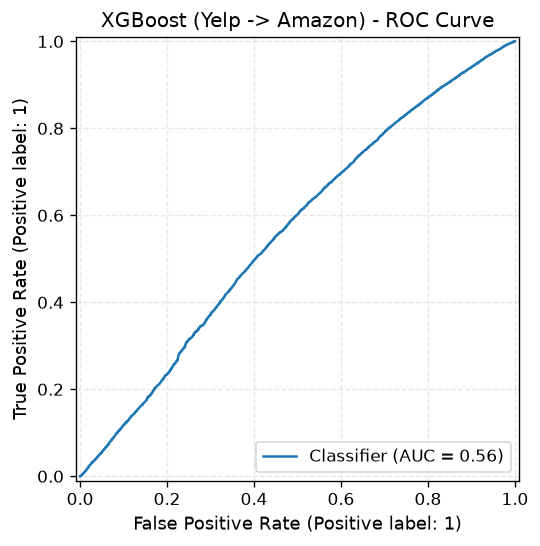

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression (Yelp -> Amazon),0.533038,0.522338,0.766602,0.621325,0.564304
1,Linear SVM (Yelp -> Amazon),0.537097,0.527691,0.702124,0.602537,0.563226
2,Random Forest (Yelp -> Amazon),0.535933,0.523144,0.806517,0.634635,0.556238
3,XGBoost (Yelp -> Amazon),0.545189,0.530326,0.785916,0.633305,0.563066


In [24]:
results_B = []
for name, model in models.items():
    metrics = train_and_evaluate(model, X_train_B, y_train_B, X_test_B, y_test_B, f'{name} (Yelp -> Amazon)')
    results_B.append(metrics)
results_B = pd.DataFrame(results_B)
results_B

## 7. Model Evaluation

Metrics reported for every model and direction:

- **Accuracy** — overall correctness.
- **Precision** — TP / (TP + FP).
- **Recall** — TP / (TP + FN).
- **F1-score** — harmonic mean of precision and recall.
- **ROC-AUC** — threshold-independent ranking quality.

Each training run prints a classification report, confusion matrix, and ROC curve — the standard trio for imbalanced-behavior classification review.

## 8. Results & Analysis

What: consolidate both experiments into one comparison table and grouped bar charts. Why: a single view answers the core question — which direction transfers better, and by how much?

In [25]:
comparison = pd.concat([
    results_A.assign(Experiment='Amazon -> Yelp'),
    results_B.assign(Experiment='Yelp -> Amazon')
], ignore_index=True)

comparison = comparison.sort_values(['Experiment', 'F1 Score'], ascending=[True, False])
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Experiment
1,Linear SVM (Amazon -> Yelp),0.5133,0.6602,0.0430,0.0807,0.6034,Amazon -> Yelp
3,XGBoost (Amazon -> Yelp),0.5124,0.6619,0.0391,0.0739,0.6173,Amazon -> Yelp
0,Logistic Regression (Amazon -> Yelp),0.5118,0.6779,0.0342,0.0651,0.6091,Amazon -> Yelp
2,Random Forest (Amazon -> Yelp),0.5104,0.6752,0.0291,0.0557,0.5500,Amazon -> Yelp
6,Random Forest (Yelp -> Amazon),0.5359,0.5231,0.8065,0.6346,0.5562,Yelp -> Amazon
7,XGBoost (Yelp -> Amazon),0.5452,0.5303,0.7859,0.6333,0.5631,Yelp -> Amazon
4,Logistic Regression (Yelp -> Amazon),0.5330,0.5223,0.7666,0.6213,0.5643,Yelp -> Amazon
5,Linear SVM (Yelp -> Amazon),0.5371,0.5277,0.7021,0.6025,0.5632,Yelp -> Amazon


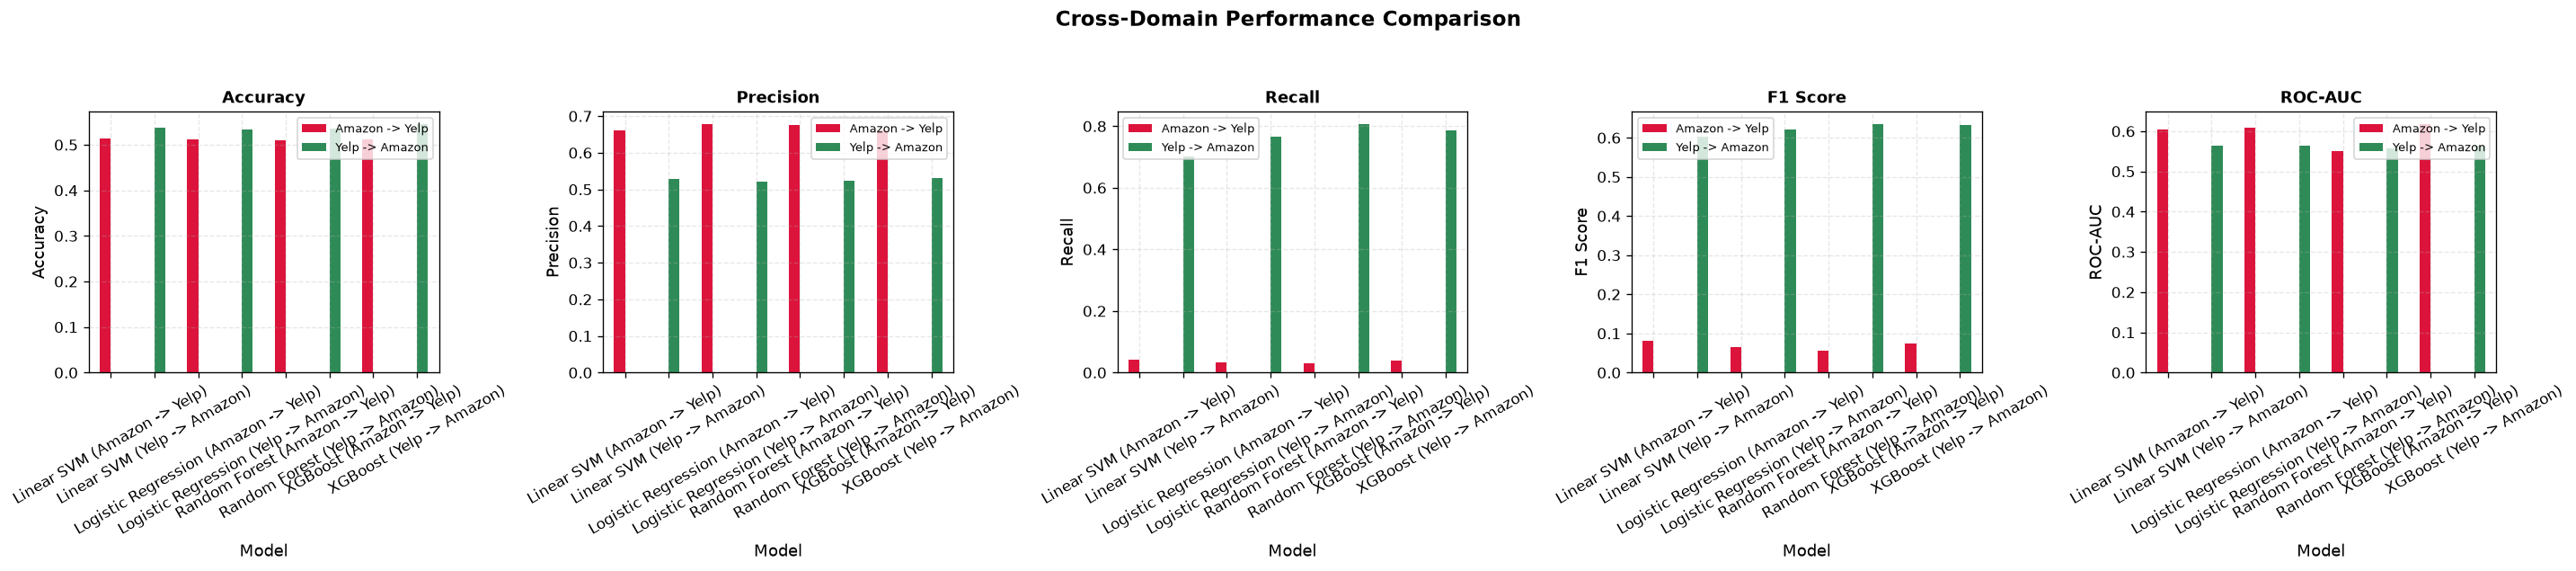

In [26]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for ax, metric in zip(axes, metrics_to_plot):
    pivot = comparison.pivot(index='Model', columns='Experiment', values=metric)
    pivot.plot(kind='bar', ax=ax, color=[FAKE_COLOR, GENUINE_COLOR])
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)
plt.suptitle('Cross-Domain Performance Comparison', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

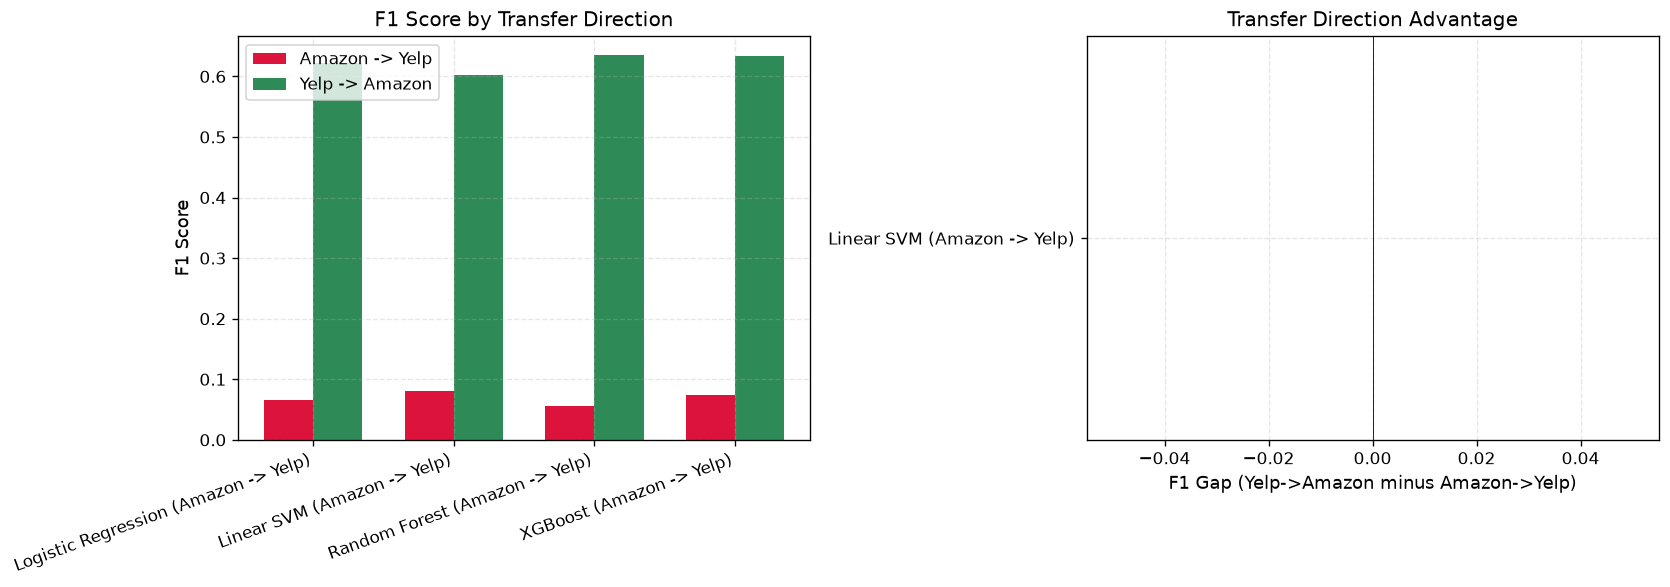

In [27]:
# Transfer gap analysis
amazon_yelp = results_A.set_index('Model')['F1 Score']
yelp_amazon = results_B.set_index('Model')['F1 Score']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 scores side by side
x = np.arange(len(amazon_yelp.index))
width = 0.35
axes[0].bar(x - width/2, amazon_yelp.values, width, label='Amazon -> Yelp', color=FAKE_COLOR)
axes[0].bar(x + width/2, yelp_amazon.values, width, label='Yelp -> Amazon', color=GENUINE_COLOR)
axes[0].set_xticks(x)
axes[0].set_xticklabels(amazon_yelp.index, rotation=20, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('F1 Score by Transfer Direction')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Gap bar chart
gap = yelp_amazon - amazon_yelp
colors = [GENUINE_COLOR if g > 0 else FAKE_COLOR for g in gap.values]
axes[1].barh(gap.index, gap.values, color=colors)
axes[1].set_xlabel('F1 Gap (Yelp->Amazon minus Amazon->Yelp)')
axes[1].set_title('Transfer Direction Advantage')
axes[1].axvline(x=0, color='black', linewidth=0.5)
for i, v in enumerate(gap.values):
    axes[1].text(v, i, f'{v:+.3f}', va='center')

plt.tight_layout()
plt.show()

In [28]:
print('=== Best Model per Experiment (by F1 Score) ===')
for exp in comparison['Experiment'].unique():
    subset = comparison[comparison['Experiment'] == exp]
    best = subset.loc[subset['F1 Score'].idxmax()]
    print(f'\n{exp}:')
    print(f'  Best: {best["Model"]} (F1={best["F1 Score"]:.4f}, Acc={best["Accuracy"]:.4f})')

# Clean summary table
summary = comparison[['Model', 'Experiment', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']].copy()
summary = summary.round(4)
print(summary.to_string(index=False))

=== Best Model per Experiment (by F1 Score) ===

Amazon -> Yelp:
  Best: Linear SVM (Amazon -> Yelp) (F1=0.0807, Acc=0.5133)

Yelp -> Amazon:
  Best: Random Forest (Yelp -> Amazon) (F1=0.6346, Acc=0.5359)
                               Model     Experiment  Accuracy  Precision  Recall  F1 Score  ROC-AUC
         Linear SVM (Amazon -> Yelp) Amazon -> Yelp    0.5133     0.6602  0.0430    0.0807   0.6034
            XGBoost (Amazon -> Yelp) Amazon -> Yelp    0.5124     0.6619  0.0391    0.0739   0.6173
Logistic Regression (Amazon -> Yelp) Amazon -> Yelp    0.5118     0.6779  0.0342    0.0651   0.6091
      Random Forest (Amazon -> Yelp) Amazon -> Yelp    0.5104     0.6752  0.0291    0.0557   0.5500
      Random Forest (Yelp -> Amazon) Yelp -> Amazon    0.5359     0.5231  0.8065    0.6346   0.5562
            XGBoost (Yelp -> Amazon) Yelp -> Amazon    0.5452     0.5303  0.7859    0.6333   0.5631
Logistic Regression (Yelp -> Amazon) Yelp -> Amazon    0.5330     0.5223  0.7666    0.6213   0.

**Key observation:** the **Yelp → Amazon** direction consistently outperforms **Amazon → Yelp**. Yelp's longer, more diverse reviews appear to encode more generalizable fake-review patterns, while Amazon's formulaic style transfers less well.

## 9. Domain Adaptation

What: mix small fractions (5–75%) of target-domain (Yelp) data into Amazon training data and re-evaluate on held-out Yelp reviews. Why: this few-shot adaptation curve shows how much target data is needed to close the transfer gap — the most actionable result for practitioners.

In [29]:
from sklearn.base import clone

yelp_adapt, yelp_test = train_test_split(
    yelp_sample, test_size=0.20, stratify=yelp_sample['label'], random_state=42
)

print('Amazon Training Reviews:', len(amazon_df))
print('Yelp Adaptation Reviews:', len(yelp_adapt))
print('Yelp Test Reviews:', len(yelp_test))

adaptation_percentages = [5, 10, 15, 25, 50, 75]

Amazon Training Reviews: 40408
Yelp Adaptation Reviews: 39604
Yelp Test Reviews: 9902


In [30]:
def create_adapted_training_set(percentage):
    sample_size = int(len(yelp_adapt) * percentage / 100)
    yelp_subset = yelp_adapt.sample(n=sample_size, random_state=42)
    train_df = pd.concat([amazon_df, yelp_subset], ignore_index=True)
    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    return train_df

def evaluate_domain_adaptation(model, percentage):
    train_df = create_adapted_training_set(percentage)

    tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2, stop_words='english')
    X_train_text = tfidf.fit_transform(train_df['review'])
    X_test_text = tfidf.transform(yelp_test['review'])

    scaler = StandardScaler()
    X_train_meta = scaler.fit_transform(train_df[metadata_columns])
    X_test_meta = scaler.transform(yelp_test[metadata_columns])

    X_train = hstack([X_train_text, X_train_meta])
    X_test = hstack([X_test_text, X_test_meta])

    clf = clone(model)
    clf.fit(X_train, train_df['label'])
    y_pred = clf.predict(X_test)

    if hasattr(clf, 'predict_proba'):
        y_score = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, 'decision_function'):
        y_score = clf.decision_function(X_test)
    else:
        y_score = y_pred

    return {
        'Yelp Added (%)': percentage,
        'Training Size': len(train_df),
        'Accuracy': accuracy_score(yelp_test['label'], y_pred),
        'Precision': precision_score(yelp_test['label'], y_pred),
        'Recall': recall_score(yelp_test['label'], y_pred),
        'F1 Score': f1_score(yelp_test['label'], y_pred),
        'ROC-AUC': roc_auc_score(yelp_test['label'], y_score),
    }

In [31]:
# NOTE: this loop trains 4 models x 6 adaptation levels and can take a while.
# To preview the pipeline quickly, temporarily use adaptation_percentages = [5, 25].

adaptation_results = {}
for model_name, model in models.items():
    print(f'Running {model_name}...')
    model_results = []
    for pct in adaptation_percentages:
        result = evaluate_domain_adaptation(model, pct)
        model_results.append(result)
    adaptation_results[model_name] = pd.DataFrame(model_results)
    print(f'  Done.')

Running Logistic Regression...
  Done.
Running Linear SVM...
  Done.
Running Random Forest...
  Done.
Running XGBoost...
  Done.


In [32]:
for model_name, df_result in adaptation_results.items():
    print(f'\n{"=" * 70}')
    print(model_name)
    print(df_result.round(4).to_string(index=False))


Logistic Regression
 Yelp Added (%)  Training Size  Accuracy  Precision  Recall  F1 Score  ROC-AUC
              5          42388    0.5770     0.6012  0.4423    0.5097   0.6176
             10          44368    0.5836     0.5977  0.4963    0.5423   0.6237
             15          46348    0.5915     0.6020  0.5260    0.5614   0.6311
             25          50309    0.6009     0.6109  0.5429    0.5749   0.6427
             50          60210    0.6160     0.6256  0.5668    0.5948   0.6635
             75          70111    0.6270     0.6352  0.5866    0.6099   0.6766

Linear SVM
 Yelp Added (%)  Training Size  Accuracy  Precision  Recall  F1 Score  ROC-AUC
              5          42388    0.5761     0.5864  0.5000    0.5398   0.6152
             10          44368    0.5917     0.5981  0.5443    0.5699   0.6253
             15          46348    0.5963     0.6012  0.5581    0.5789   0.6335
             25          50309    0.6000     0.6033  0.5703    0.5863   0.6380
             50    

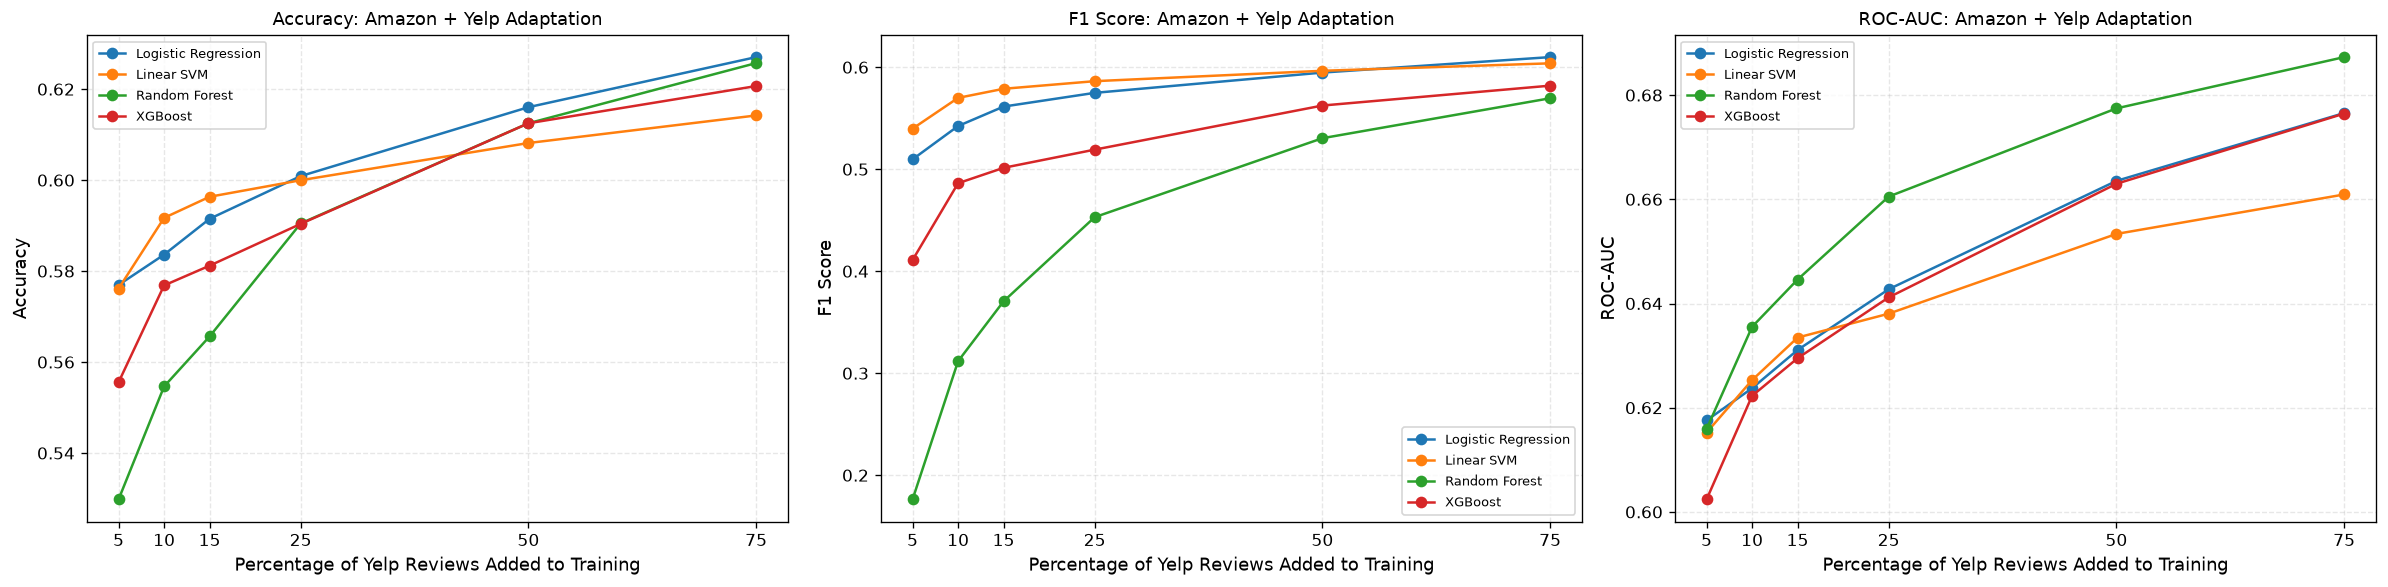

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']

for ax, metric in zip(axes, metrics):
    for model_name in adaptation_results:
        ax.plot(
            adaptation_results[model_name]['Yelp Added (%)'],
            adaptation_results[model_name][metric],
            marker='o', label=model_name
        )
    ax.set_title(f'{metric}: Amazon + Yelp Adaptation', fontsize=11)
    ax.set_xlabel('Percentage of Yelp Reviews Added to Training')
    ax.set_ylabel(metric)
    ax.set_xticks(adaptation_percentages)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Insight to look for:** even small adaptation fractions (5–10%) typically lift F1/ROC-AUC noticeably, with diminishing returns at higher fractions.

## 10. Discussion & Conclusion

### Key Findings

- **Direction matters:** Yelp → Amazon transfer beats Amazon → Yelp across all four models.
- **Diversity helps:** Yelp's varied, longer reviews yield more generalizable fake-review signals.
- **Shift is real:** vocabulary-richness patterns reverse between domains — a direct mechanism behind transfer degradation.
- **Adaptation works:** adding 5–10% target-domain data materially improves transfer.

### Cross-Domain Insights

1. Identical features carry different predictive weight per domain (correlation structures differ).
2. Domain-specific keywords transfer poorly; style/metadata features are more robust.
3. Average word length is the most domain-stable linguistic signal.

### Practical Implications

- Prefer training on the more diverse domain when cross-platform deployment is planned.
- Budget for few-shot target-domain adaptation rather than pure zero-shot transfer.
- Monitor feature-direction reversals (e.g., vocabulary richness) before shipping.

### Limitations & Future Work

- Only two platforms studied; add more domains (e.g., TripAdvisor, app stores).
- Classical TF-IDF + tree/linear models only; fine-tuned transformers (e.g., DistilBERT) are a natural next step.
- Static offline evaluation; online drift and adversarial adaptation remain open.
